# MODIS vs HLS Phenometric comparisons

**Purpose:** Compare the in development HLS phenometrics to the [MCD12Q2 v6.1](https://modis-land.gsfc.nasa.gov/pdf/MCD12Q2_Collection6_UserGuide.pdf) land cover dynamics phenometrics. MODIS12Q2 is derived from NBAR-EVI2 time series, eliminates outliers, fills dormant period values, applies a cubic spline, IDs valid vegetation cycles within the time series, and extracs phenometrics for each vegetation cycle.

## Key Questions:
- How do phenophase dates compare across datasets for ROI?
- 

## To Do
MODIS comparison
- [ ] Compare to MCD12Q2 6.1 BRDF EVI2 products
    - [x] import MODIS
    - [x] Adjust to ROI/Period overlap
    - [x] Plot time series for whole tile
    - [x] pick representative pixels and compare 

In [30]:
import xarray as xr
import rioxarray as rxr
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import mapping
from shapely.geometry import box

import pyproj
from pyproj import Transformer, CRS
import matplotlib.pyplot as plt
import os
from pathlib import Path

import subprocess
import re

In [9]:
import earthaccess
import mgrs
# Authenticate with NASA EarthData (will prompt for credentials if not cached)
# Register for free at: https://urs.earthdata.nasa.gov/
earthaccess.login(strategy="interactive", persist=True)

In [10]:
# roi_name = "MD_transect" # Patuxent | MD_transect | SERC_shpfile
# SHP_PATH = Path(f"/projects/my-public-bucket/hls/testing/ROIs/{roi_name}/POLYGON.shp")

In [11]:
def load_shapefile(shp_path):
    gdf = gpd.read_file(shp_path)
    print(f"Shapefile CRS: {gdf.crs}")
    print(f"Number of features: {len(gdf)}")
    print(f"Geometry types: {gdf.geom_type.unique()}")

    # Reproject to WGS84 for earthaccess bbox search
    if gdf.crs.to_epsg() != 4326:
        print("Reprojecting shapefile to WGS84 (EPSG:4326)...")
        gdf_wgs84 = gdf.to_crs(epsg=4326)
    else:
        gdf_wgs84 = gdf

    # Get bounding box for granule search
    bounds = gdf_wgs84.total_bounds  # (minx, miny, maxx, maxy)
    bbox = (bounds[0], bounds[1], bounds[2], bounds[3])
    
    return gdf, gdf_wgs84, bbox

def get_bbox_from_mgrs_tile(tile_id):
    m = mgrs.MGRS()
    
    # Get corners of the MGRS tile
    # MGRS tiles are 100km x 100km
    sw_mgrs = f"{tile_id}0000000000"  # Southwest corner
    ne_mgrs = f"{tile_id}9999999999"  # Northeast corner
    
    # Convert to lat/lon
    sw_lat, sw_lon = m.toLatLon(sw_mgrs) 
    ne_lat, ne_lon = m.toLatLon(ne_mgrs)
    
    print(f"MGRS Tile: {tile_id}")
    print(f"  SW corner: ({sw_lat:.4f}, {sw_lon:.4f})")
    print(f"  NE corner: ({ne_lat:.4f}, {ne_lon:.4f})")
    
    # Create bounding box for earthaccess (lon_min, lat_min, lon_max, lat_max)
    bbox = (sw_lon, sw_lat, ne_lon, ne_lat)
    
    # Create GeoDataFrame in WGS84
    geom_wgs84 = box(sw_lon, sw_lat, ne_lon, ne_lat)
    gdf_wgs84 = gpd.GeoDataFrame({'geometry': [geom_wgs84]}, crs='EPSG:4326')
    
    # Also create in UTM for clipping rasters later
    zone_num = int(tile_id[:2])
    lat_band = tile_id[2]
    hemisphere = 'north' if lat_band >= 'N' else 'south'
    utm_epsg = 32600 + zone_num if hemisphere == 'north' else 32700 + zone_num
    
    gdf = gdf_wgs84.to_crs(epsg=utm_epsg)
    
    print(f"  BBox (WGS84): {bbox}")
    print(f"  UTM CRS: EPSG:{utm_epsg}")
    
    return gdf, gdf_wgs84, bbox

In [8]:
#gdf, gdf_wgs84, bbox = load_shapefile(SHP_PATH)

In [12]:
def search_mcd12q2(bbox, years):
    all_granules = []

    for year in years:
        print(f"Searching for year {year}...")
        
        results = earthaccess.search_data(
            short_name="MCD12Q2",       
            version="061",              # v6.1 = "061"
            bounding_box=bbox,          # (lon_min, lat_min, lon_max, lat_max)
            temporal=(f"{year}-01-01", f"{year}-12-31"),
            count=50                    # Max granules per query
        )
        
        print(f"  Found {len(results)} granule(s) for {year}")
        all_granules.extend(results)

    print(f"\nTotal granules found: {len(all_granules)}")
    return all_granules

In [16]:
def download_in_batches(granules, output_dir="/tmp/MCD12Q2_data", batch_size=1):
    """
    Download granules one at a time to avoid connection timeouts.
    """
    os.makedirs(output_dir, exist_ok=True)
    all_files = []

    for i in range(0, len(granules), batch_size):
        batch = granules[i:i+batch_size]
        print(f"Downloading batch {i//batch_size + 1} ({len(batch)} granule(s))...")
        
        try:
            files = earthaccess.download(batch, output_dir)
            all_files.extend(files)
        except OSError as e:
            if "107" in str(e):
                print(f"  Filesystem error on batch {i//batch_size + 1} — skipping")
                print(f"  Consider switching to streaming with earthaccess.open()")
            else:
                raise e

    return all_files

In [27]:
TILE_ID = "03WWM"  
gdf, gdf_wgs84, bbox = get_bbox_from_mgrs_tile(TILE_ID)
st_year = 2021
end_year = 2024
outdir = Path(f"output/{TILE_ID}/MODIS/")
outdir.mkdir(exist_ok=True)

years = list(range(st_year, end_year + 1))  # 2018–2024 Support ended in 2025
print(years)

MGRS Tile: 03WWM
  SW corner: (64.0268, -165.0000)
  NE corner: (64.9091, -162.8863)
  BBox (WGS84): (-165.00000000000003, 64.02679492141058, -162.88629901929158, 64.90913809710288)
  UTM CRS: EPSG:32603
[2021, 2022, 2023, 2024]


In [28]:
granules = search_mcd12q2(bbox, years)

Searching for year 2021...
  Found 2 granule(s) for 2021
Searching for year 2022...
  Found 2 granule(s) for 2022
Searching for year 2023...
  Found 2 granule(s) for 2023
Searching for year 2024...
  Found 2 granule(s) for 2024

Total granules found: 8


In [29]:
downloaded_files = download_in_batches(granules, output_dir = outdir)

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

...

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
import s3fs
import earthaccess
import os
def download_to_s3(granules, s3_bucket, s3_prefix="MCD12Q2_data"):
    fs = s3fs.S3FileSystem(anon=False)

    s3_paths = []

    for i, granule in enumerate(granules):
        urls = earthaccess.results.DataGranule.data_links(granule, access="external")
        filename = os.path.basename(urls[0])
        s3_path = f"{s3_bucket}/{s3_prefix}/{filename}"

        print(f"\nTransferring granule {i+1}/{len(granules)}: {filename}")
        print(f"  s3://{s3_path}")

        try:
            # Stream from NASA and write directly to S3
            with earthaccess.open([granule])[0] as src:
                with fs.open(s3_path, "wb") as dst:
                    while chunk := src.read(1024 * 1024):  # 1MB chunks
                        dst.write(chunk)

            print(f"  Success")
            s3_paths.append(f"s3://{s3_path}")

        except Exception as e:
            print(f"  Failed: {e}")

    print(f"\nComplete: {len(s3_paths)}/{len(granules)} granules written to S3")
    return s3_paths

In [ ]:
# Usage
S3_BUCKET = "maap-ops-workspace"   
S3_PREFIX = "shared/colinquinn/hls/testing/phenometrics/MCD12Q2" 

s3_paths = download_to_s3(granules, S3_BUCKET, S3_PREFIX)
# outdir = Path("s3://maap-ops-workspace/shared/colinquinn/hls/testing/phenometrics/MCD12Q2/")
# downloaded_files = download_granules(granules, output_dir = outdir)

# HDF NOT COOPERATING - use terminal gdal to convert each layer to geotiff

In [33]:
import subprocess
import re
from pathlib import Path
from collections import defaultdict

In [35]:
# Step 1: Extract all subdatasets, keeping tiles separate
tile_files = defaultdict(lambda: defaultdict(list))  # {layer: {year: [file_paths]}}

for file_path in outdir.glob("*.hdf"):
    print(f"Processing: {file_path.name}")
    
    filename_parts = file_path.stem.split(".")
    year = int(filename_parts[1][1:5])
    tile = filename_parts[2]
    
    result = subprocess.run(
        ["gdalinfo", file_path],
        capture_output=True,
        text=True,
        check=True
    )
    txt = result.stdout
    sds_names = re.findall(r'SUBDATASET_\d+_NAME=(.+)', txt)
    
    # Extract each subdataset to temp file
    temp_dir = outdir / "temp_tiles"
    temp_dir.mkdir(exist_ok=True)
    
    for sds in sds_names:
        layer_name = sds.split(":")[-1]
        temp_fp = temp_dir / f"MCD12Q2-{layer_name}_{tile}_{year}.tif"
        
        if not temp_fp.exists():
            cmd = ["gdal_translate", "-q", sds, str(temp_fp)]
            subprocess.run(cmd, check=True)
        
        # Track files for mosaicking
        tile_files[layer_name][year].append(str(temp_fp))


Processing: MCD12Q2.A2021001.h11v02.061.2022294172708.hdf
Processing: MCD12Q2.A2024001.h11v02.061.2025216140103.hdf
Processing: MCD12Q2.A2024001.h10v02.061.2025216140100.hdf
Processing: MCD12Q2.A2022001.h10v02.061.2023221152750.hdf
Processing: MCD12Q2.A2023001.h11v02.061.2024211040644.hdf
Processing: MCD12Q2.A2022001.h11v02.061.2023221155102.hdf
Processing: MCD12Q2.A2021001.h10v02.061.2022294172623.hdf
Processing: MCD12Q2.A2023001.h10v02.061.2024211033505.hdf

Step 2: Mosaicking tiles


In [36]:
# Step 2: Mosaic tiles for each layer-year combination
print("\n" + "="*60)
print("Step 2: Mosaicking tiles")
print("="*60)
mosaic_dir = outdir / "mosaicked"
mosaic_dir.mkdir(exist_ok=True)

for layer_name, years_dict in tile_files.items():
    for year, file_list in years_dict.items():
        
        if len(file_list) == 1:
            # Only one tile, just copy
            import shutil
            out_fp = mosaic_dir / f"MCD12Q2-{layer_name}_{year}.tif"
            shutil.copy(file_list[0], out_fp)
            print(f"  {layer_name} {year}: Single tile (copied)")
        
        else:
            # Multiple tiles, mosaic them
            out_fp = mosaic_dir / f"MCD12Q2-{layer_name}_{year}.tif"
            
            print(f"  {layer_name} {year}: Mosaicking {len(file_list)} tiles...")
            
            # Use gdal_merge.py or gdalwarp
            cmd = [
                "gdal_merge.py",
                "-o", str(out_fp),
                "-co", "COMPRESS=LZW",
                "-co", "TILED=YES",
                "-n", "32767",  # MODIS nodata value
                "-a_nodata", "32767",
                *file_list
            ]
            
            result = subprocess.run(cmd, capture_output=True, text=True)
            
            if result.returncode != 0:
                print(f"    ✗ Failed: {result.stderr}")
            else:
                print(f"    ✓ Saved: {out_fp.name}")


Step 2: Mosaicking tiles
  NumCycles 2021: Mosaicking 2 tiles...
    ✓ Saved: MCD12Q2-NumCycles_2021.tif
  NumCycles 2024: Mosaicking 2 tiles...
    ✓ Saved: MCD12Q2-NumCycles_2024.tif
  NumCycles 2022: Mosaicking 2 tiles...
    ✓ Saved: MCD12Q2-NumCycles_2022.tif
  NumCycles 2023: Mosaicking 2 tiles...
    ✓ Saved: MCD12Q2-NumCycles_2023.tif
  Greenup 2021: Mosaicking 2 tiles...
    ✓ Saved: MCD12Q2-Greenup_2021.tif
  Greenup 2024: Mosaicking 2 tiles...
    ✓ Saved: MCD12Q2-Greenup_2024.tif
  Greenup 2022: Mosaicking 2 tiles...
    ✓ Saved: MCD12Q2-Greenup_2022.tif
  Greenup 2023: Mosaicking 2 tiles...
    ✓ Saved: MCD12Q2-Greenup_2023.tif
  MidGreenup 2021: Mosaicking 2 tiles...
    ✓ Saved: MCD12Q2-MidGreenup_2021.tif
  MidGreenup 2024: Mosaicking 2 tiles...
    ✓ Saved: MCD12Q2-MidGreenup_2024.tif
  MidGreenup 2022: Mosaicking 2 tiles...
    ✓ Saved: MCD12Q2-MidGreenup_2022.tif
  MidGreenup 2023: Mosaicking 2 tiles...
    ✓ Saved: MCD12Q2-MidGreenup_2023.tif
  Peak 2021: Mosaickin

In [39]:
def clip_tifs_to_mgrs(input_dir, output_dir, mgrs_tile):
    """
    Reproject MODIS to UTM and clip to MGRS tile bounds.
    
    Args:
        input_dir (Path): Directory with MODIS TIFs (Sinusoidal projection)
        output_dir (Path): Directory for clipped TIFs
        mgrs_tile (str): MGRS tile ID
    """
    import mgrs as mgrs_lib
    
    input_dir = Path(input_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True, parents=True)
    
    # Get MGRS bounds in WGS84
    m = mgrs_lib.MGRS()
    sw_mgrs = f"{mgrs_tile}0000000000"
    ne_mgrs = f"{mgrs_tile}9999999999"
    
    sw_lat, sw_lon = m.toLatLon(sw_mgrs)
    ne_lat, ne_lon = m.toLatLon(ne_mgrs)
    
    # Determine target UTM CRS from MGRS tile
    zone_num = int(mgrs_tile[:2])
    lat_band = mgrs_tile[2]
    hemisphere = 'north' if lat_band >= 'N' else 'south'
    utm_epsg = 32600 + zone_num if hemisphere == 'north' else 32700 + zone_num
    
    print(f"Clipping to MGRS tile {mgrs_tile}")
    print(f"  Bounds (WGS84): [{sw_lon}, {sw_lat}, {ne_lon}, {ne_lat}]")
    print(f"  Target CRS: EPSG:{utm_epsg}")
    
    # Convert WGS84 bounds to UTM for clipping
    from pyproj import Transformer
    transformer = Transformer.from_crs("EPSG:4326", f"EPSG:{utm_epsg}", always_xy=True)
    
    # Transform corners
    sw_x, sw_y = transformer.transform(sw_lon, sw_lat)
    ne_x, ne_y = transformer.transform(ne_lon, ne_lat)
    
    utm_bounds = [sw_x, sw_y, ne_x, ne_y]
    print(f"  Bounds (UTM): {utm_bounds}")
    
    for tif_path in sorted(input_dir.glob("MCD12Q2-*.tif")):
        out_path = output_dir / tif_path.name
        
        if out_path.exists():
            print(f"  ✓ {tif_path.name} (exists, skipping)")
            continue
        
        print(f"  Processing {tif_path.name}...")
        
        cmd = [
            "gdalwarp",
            "-q",
            "-t_srs", f"EPSG:{utm_epsg}",  # Reproject to UTM
            "-te",  # target extent in target CRS (UTM)
            str(utm_bounds[0]),  # xmin
            str(utm_bounds[1]),  # ymin
            str(utm_bounds[2]),  # xmax
            str(utm_bounds[3]),  # ymax
            "-tr", "500", "500",  # Maintain 500m resolution
            "-r", "near",  # Nearest neighbor for discrete values (DOY)
            "-co", "COMPRESS=LZW",
            "-co", "TILED=YES",
            "-srcnodata", "32767",
            "-dstnodata", "32767",
            str(tif_path),
            str(out_path)
        ]
        
        result = subprocess.run(cmd, capture_output=True, text=True)
        
        if result.returncode != 0:
            print(f"    ✗ Failed: {result.stderr}")
        else:
            print(f"    ✓ Saved")
    
    print(f"\n✅ Complete! Clipped files in: {output_dir}")


# Clip all to MGRS bounds
CLIPPED_DIR = outdir / "clipped"
clip_tifs_to_mgrs(outdir / "mosaicked", CLIPPED_DIR, mgrs_tile=TILE_ID)

Clipping to MGRS tile 03WWM
  Bounds (WGS84): [-165.00000000000003, 64.02679492141058, -162.88629901929158, 64.90913809710288]
  Target CRS: EPSG:32603
  Bounds (UTM): [499999.9999999975, 7100000.000000047, 599998.9999999739, 7199999.000000042]
  Processing MCD12Q2-Dormancy_2021.tif...
    ✓ Saved
  Processing MCD12Q2-Dormancy_2022.tif...
    ✓ Saved
  Processing MCD12Q2-Dormancy_2023.tif...
    ✓ Saved
  Processing MCD12Q2-Dormancy_2024.tif...
    ✓ Saved
  Processing MCD12Q2-EVI_Amplitude_2021.tif...
    ✓ Saved
  Processing MCD12Q2-EVI_Amplitude_2022.tif...
    ✓ Saved
  Processing MCD12Q2-EVI_Amplitude_2023.tif...
    ✓ Saved
  Processing MCD12Q2-EVI_Amplitude_2024.tif...
    ✓ Saved
  Processing MCD12Q2-EVI_Area_2021.tif...
    ✓ Saved
  Processing MCD12Q2-EVI_Area_2022.tif...
    ✓ Saved
  Processing MCD12Q2-EVI_Area_2023.tif...
    ✓ Saved
  Processing MCD12Q2-EVI_Area_2024.tif...
    ✓ Saved
  Processing MCD12Q2-EVI_Minimum_2021.tif...
    ✓ Saved
  Processing MCD12Q2-EVI_Minim

In [37]:
temp_dir

PosixPath('output/03WWM/MODIS/temp_tiles')

In [ ]:
# Optionally: Clean up temp files
import shutil
shutil.rmtree(temp_dir)

In [31]:
for file_path in outdir.glob("*.hdf"):
    print(file_path)
    
    result = subprocess.run(
        ["gdalinfo", file_path],
        capture_output=True,
        text=True,
        check=True
    )
    txt = result.stdout
    sds_names = re.findall(r'SUBDATASET_\d+_NAME=(.+)', txt)
    
    print(f"   Found {len(sds_names)} subdatasets")
    year = int(sds_names[0].split(".")[1][1:5])
    print(f"   {year}")

    for sds in sds_names:
        layer_name = sds.split(":")[-1]
        out_fp = outdir / f"MCD12Q2-{layer_name}_{year}.tif"
        print(f"      Outfile: {out_fp}")
        cmd = ["gdal_translate", sds, str(out_fp)]
        print("      Extracting:", layer_name)
        subprocess.run(cmd, check=True)

output/03WWM/MODIS/MCD12Q2.A2021001.h11v02.061.2022294172708.hdf
   Found 13 subdatasets
   2021
      Outfile: output/03WWM/MODIS/MCD12Q2-NumCycles_2021.tif
      Extracting: NumCycles
Input file size is 2400, 2400
0...10...20...30...40...50...60...70...80...90...100 - done.
      Outfile: output/03WWM/MODIS/MCD12Q2-Greenup_2021.tif
      Extracting: Greenup
Input file size is 2400, 2400
0...10...20...30...40...50...60...70...80...90...100 - done.
      Outfile: output/03WWM/MODIS/MCD12Q2-MidGreenup_2021.tif
      Extracting: MidGreenup
Input file size is 2400, 2400
0...10...20...30...40...50...60...70...80...90...100 - done.
      Outfile: output/03WWM/MODIS/MCD12Q2-Peak_2021.tif
      Extracting: Peak
Input file size is 2400, 2400
0...10...20...30...40...50...60...70...80...90...100 - done.
      Outfile: output/03WWM/MODIS/MCD12Q2-Maturity_2021.tif
      Extracting: Maturity
Input file size is 2400, 2400
0...10...20...30...40...50...60...70...80...90...100 - done.
      Outfile: ou


KeyboardInterrupt



# Read in new MODIS tifs 

In [275]:
TILE_ID     = "03WWM"

MODIS_DIR   = Path(f"output/{TILE_ID}/MODIS/mosaicked/")
HLS_DIR     = Path(f"output/{TILE_ID}/")
OUTPUT_DIR  = Path(f"output/{TILE_ID}/MODIS/")
NLCD_DIR =  Path('/projects/my-public-bucket/hls/nlcd_annual_landcover/') 
OUTPUT_DIR.mkdir(exist_ok=True)

YEARS       = list(range(2021, 2024+1))
# YEARS       = [2019]
# TARGET_CRS  = "EPSG:32618"   # UTM Zone 18N — HLS native CRS

In [276]:
VAR_PAIRS = {
    # HLS                  # MCD12Q2
    "greenup_doy"          : "Greenup",
    "max_doy"              : "Peak",
    "min_doy"              : "Dormancy",

    "amplitude"            : "EVI_Amplitude",
    "min_evi"              : "EVI_Minimum",
    
    "max_evi"              : "DERIVED_Amplitude_plus_Minimum",
    "growing_season_length": "DERIVED_Dormancy_minus_Greenup", 
}

In [277]:
def load_custom_phenometrics(custom_dir, years, var_pairs, gdf, mask_to_decid_for = False, TARGET_CRS = None):
    custom_vars = [v for v in var_pairs.keys()]
    data = {var: {} for var in custom_vars}

    for year in years:
        for var in custom_vars:
            # Filename pattern: greenup_doy_2018.tif
            fp = custom_dir / str(year) / f"{var}_{year}.tif"

            try:
                da = rxr.open_rasterio(fp, masked=True).squeeze()
                if da.rio.crs.to_epsg() == None or TARGET_CRS:
                    da = da.rio.write_crs(TARGET_CRS)

                if mask_to_decid_for:
                    nlcd_file_year = f"{NLCD_DIR}/masks/{year}/{year}_41_Forest.tif"
                    nlcd_mask_y = rxr.open_rasterio(nlcd_file_year, masked=True).squeeze().drop_vars(['band', 'spatial_ref'])
                    nlcd_mask_y = nlcd_mask_y.rio.write_crs(TARGET_CRS)
                    da = da.where(nlcd_mask_y == 1)

                data[var][year] = da
                print(f"  {var} {year} — shape: {da.shape}")
                
            except Exception as e:
                print(f"  {var} {year}: {e}")

    return data

In [278]:
print("Loading custom phenometrics...")
custom_data = load_custom_phenometrics(HLS_DIR, YEARS, VAR_PAIRS, gdf, mask_to_decid_for = False)

Loading custom phenometrics...
  greenup_doy 2021 — shape: (3660, 3660)
  max_doy 2021 — shape: (3660, 3660)
  min_doy 2021 — shape: (3660, 3660)
  amplitude 2021 — shape: (3660, 3660)
  min_evi 2021 — shape: (3660, 3660)
  max_evi 2021 — shape: (3660, 3660)
  growing_season_length 2021 — shape: (3660, 3660)
  greenup_doy 2022 — shape: (3660, 3660)
  max_doy 2022 — shape: (3660, 3660)
  min_doy 2022 — shape: (3660, 3660)
  amplitude 2022 — shape: (3660, 3660)
  min_evi 2022 — shape: (3660, 3660)
  max_evi 2022 — shape: (3660, 3660)
  growing_season_length 2022 — shape: (3660, 3660)
  greenup_doy 2023 — shape: (3660, 3660)
  max_doy 2023 — shape: (3660, 3660)
  min_doy 2023 — shape: (3660, 3660)
  amplitude 2023 — shape: (3660, 3660)
  min_evi 2023 — shape: (3660, 3660)
  max_evi 2023 — shape: (3660, 3660)
  growing_season_length 2023 — shape: (3660, 3660)
  greenup_doy 2024 — shape: (3660, 3660)
  max_doy 2024 — shape: (3660, 3660)
  min_doy 2024 — shape: (3660, 3660)
  amplitude 2024 

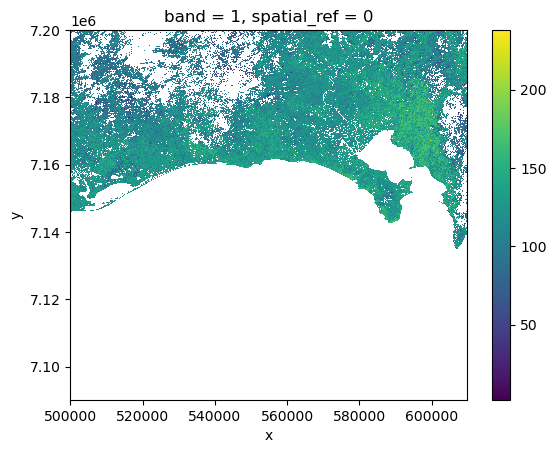

In [156]:
custom_data['growing_season_length'][2021].plot()

In [77]:
da = custom_data['greenup_doy'][2021]
trimmed = da.dropna(dim='y', how='all').dropna(dim='x', how='all')
bounds = trimmed.rio.bounds()
bbox_gdf = gpd.GeoDataFrame(
    {'geometry': [box(*bounds)]},
    crs=da.rio.crs
)

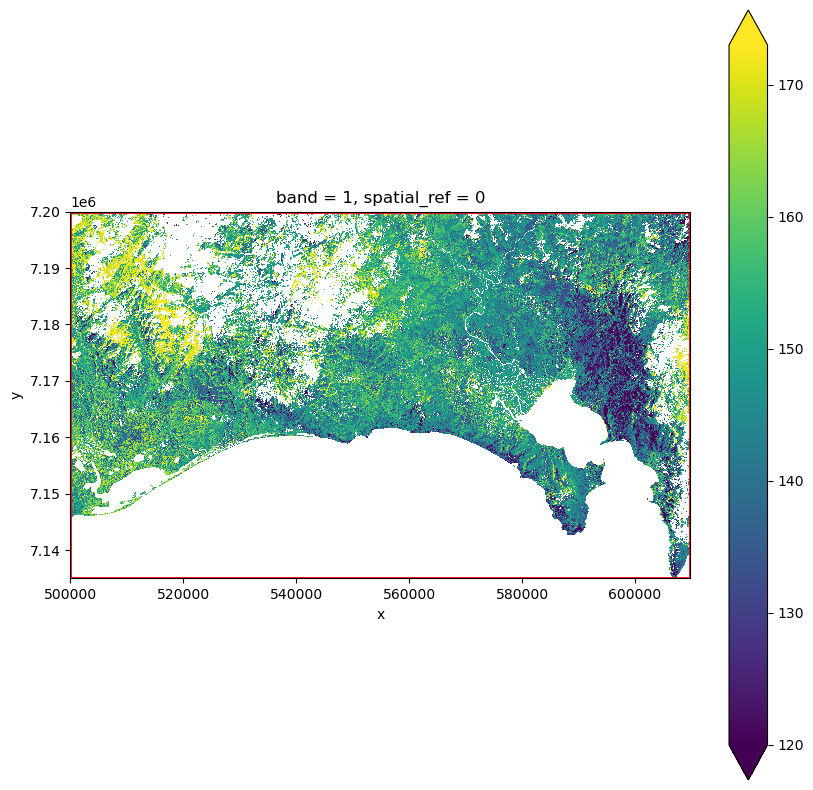

In [78]:
# Plot
fig, ax = plt.subplots(figsize=(10, 10))
trimmed.plot(ax=ax, robust=True)
bbox_gdf.boundary.plot(ax=ax, color='red', linewidth=2)
plt.show()

In [79]:
import rioxarray
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

In [157]:
def plot_extent_diagnostic(
    modis_tif,
    custom_tif,
    gdf,
    modis_var="Greenup_1",
    custom_var="greenup_doy",
    year=2018
):
    """
    Plot raw MODIS and custom HLS rasters with shapefile boundary overlaid.
    Helps diagnose CRS/extent mismatches causing empty clips.

    Args:
        modis_tif (str/Path): Path to a raw MODIS TIF (unclipped)
        custom_tif (str/Path): Path to a custom HLS TIF (unclipped)
        shp_path (str/Path): Path to shapefile
        modis_var (str): Variable name for plot title
        custom_var (str): Variable name for plot title
        year (int): Year for plot title
    """
    # ---- Load rasters ----
    modis = rxr.open_rasterio(modis_tif, masked=True)
    custom = rxr.open_rasterio(custom_tif, masked=True).squeeze()
    
    if modis.shape[0] == 2:
        print(f"    Two bands found — selecting band 1 (primary cycle)")
        modis = modis.sel(band=1)
    elif modis.shape[0] == 1:
        modis = modis.squeeze()
    else:
        print(f"    Unexpected band count: {modis.shape[0]} — selecting band 1")
        modis = modis.sel(band=1)
    
    gdf_modis_crs  = gdf.to_crs(modis.rio.crs)
    gdf_custom_crs = gdf.to_crs(custom.rio.crs)

    # ---- Print CRS and bounds info ----
    print("=" * 60)
    print("MODIS TIF")
    print(f"  CRS    : {modis.rio.crs}")
    print(f"  Shape  : {modis.shape}")
    print(f"  Bounds : {modis.rio.bounds()}")
    print(f"  NoData : {modis.rio.nodata}")

    print("\nCustom HLS TIF")
    print(f"  CRS    : {custom.rio.crs}")
    print(f"  Shape  : {custom.shape}")
    print(f"  Bounds : {custom.rio.bounds()}")
    print(f"  NoData : {custom.rio.nodata}")

    print("\nShapefile")
    print(f"  CRS    : {gdf.crs}")
    print(f"  Bounds : {gdf.total_bounds}")
    print(f"  Features: {len(gdf)}")
    print("=" * 60)

    def get_zoom_extent(gdf_reproj, buffer_frac=0.5):
        """
        Get zoomed axis limits with a fractional buffer around shapefile bounds.
        e.g. buffer_frac=0.5 adds 50% of the shapefile width/height on each side
        """
        minx, miny, maxx, maxy = gdf_reproj.total_bounds
        x_buf = (maxx - minx) * buffer_frac
        y_buf = (maxy - miny) * buffer_frac
        return (
            minx - x_buf,
            maxx + x_buf,
            miny - y_buf,
            maxy + y_buf
        )

    modis_zoom  = get_zoom_extent(gdf_modis_crs)
    custom_zoom = get_zoom_extent(gdf_custom_crs)
    # ---- Check if shapefile overlaps each raster ----
    def check_overlap(raster, gdf_reproj, name):
        from shapely.geometry import box
        raster_bbox = box(*raster.rio.bounds())
        shp_bbox = gdf_reproj.union_all().envelope
        overlaps = raster_bbox.intersects(shp_bbox)
        print(f"  {name} overlaps shapefile: {overlaps}")
        if not overlaps:
            print(f"    !! NO OVERLAP — likely a CRS or extent mismatch")
        return overlaps

    print("\nOverlap checks:")
    modis_overlap  = check_overlap(modis,  gdf_modis_crs,  "MODIS")
    custom_overlap = check_overlap(custom, gdf_custom_crs, "Custom HLS")

    # ---- Plot ----
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    raster_configs = [
        # (ax, raster, gdf_reproj, zoom_extent, title_prefix, var_name, zoom)
        (axes[0], modis,  gdf_modis_crs,  modis_zoom,  "MODIS MCD12Q2 — Zoomed",      modis_var,  True),
        (axes[1], custom, gdf_custom_crs, custom_zoom, "Custom HLS",                  custom_var, True),
    ]
    for ax, raster, gdf_reproj, zoom, title_prefix, var_name, is_zoomed in raster_configs:
        bounds = raster.rio.bounds()

        im = ax.imshow(
            raster.values,
            extent=[bounds[0], bounds[2], bounds[1], bounds[3]],
            cmap="RdYlGn",
            origin="upper",
            aspect="auto"
        )

        # Shapefile boundary
        gdf_reproj.boundary.plot(
            ax=ax, edgecolor="blue", linewidth=1.5, label="Shapefile"
        )

        # Shapefile bounding box
        shp_bounds = gdf_reproj.total_bounds
        shp_rect = plt.Rectangle(
            (shp_bounds[0], shp_bounds[1]),
            shp_bounds[2] - shp_bounds[0],
            shp_bounds[3] - shp_bounds[1],
            fill=False, edgecolor="red", linewidth=2,
            linestyle="--", label="Shapefile BBox"
        )
        ax.add_patch(shp_rect)

        # Apply zoom if requested
        if is_zoomed and zoom:
            ax.set_xlim(zoom[0], zoom[1])
            ax.set_ylim(zoom[2], zoom[3])

        plt.colorbar(im, ax=ax, label=var_name, shrink=0.8)
        ax.set_title(
            f"{title_prefix} — {year}\n",
            fontsize=9
        )
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.legend(fontsize=8, loc="lower right")

    plt.suptitle(
        f"Extent Diagnostic — {year}\n"
        f"Blue = Shapefile boundary   Red dashed = Shapefile bbox",
        fontsize=12, fontweight="bold"
    )
    plt.tight_layout()
    # plt.savefig(OUTPUT_DIR / "extent_diagnostic.png", dpi=150, bbox_inches="tight")
    plt.show()
    # print(f"\nSaved: extent_diagnostic.png")

    Two bands found — selecting band 1 (primary cycle)
MODIS TIF
  CRS    : PROJCS["unnamed",GEOGCS["Unknown datum based upon the custom spheroid",DATUM["Not specified (based on custom spheroid)",SPHEROID["Custom spheroid",6371007.181,0]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Sinusoidal"],PARAMETER["longitude_of_center",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
  Shape  : (2400, 4800)
  Bounds : (-8895604.157333, 6671703.117999999, -6671703.117998998, 7783653.637667)
  NoData : nan

Custom HLS TIF
  CRS    : EPSG:32603
  Shape  : (3660, 3660)
  Bounds : (499980.0, 7090200.0, 609780.0, 7200000.0)
  NoData : nan

Shapefile
  CRS    : PROJCS["WGS 84 / UTM zone 3N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901

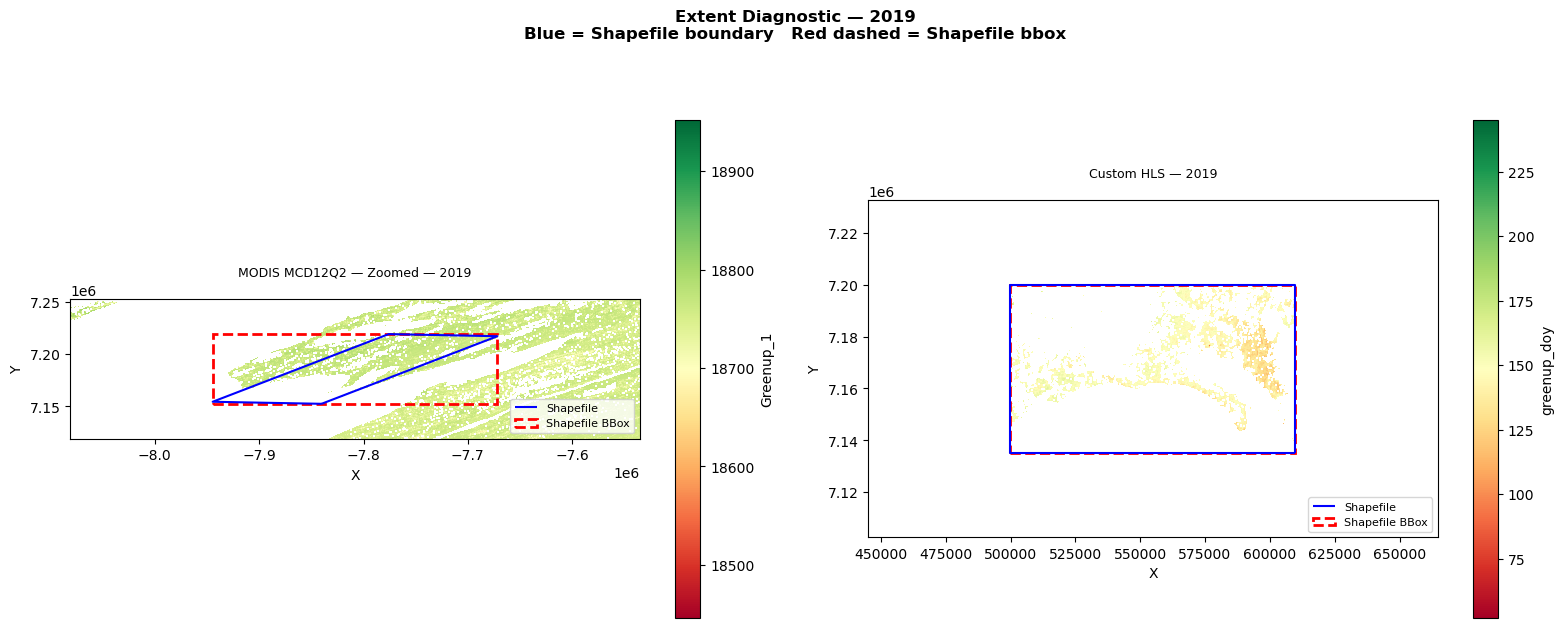

In [83]:
# ---- Run on one year to diagnose ----
plot_extent_diagnostic(
    modis_tif  = MODIS_DIR / f"MCD12Q2-Greenup_{years[0]}.tif",
    custom_tif = HLS_DIR / str(years[0]) / f"greenup_doy_{years[0]}.tif",
    gdf   = bbox_gdf,
    modis_var  = "Greenup_1",
    custom_var = "greenup_doy",
    year       = 2019
)

In [279]:
def days_since_1970_to_doy(da):
    """
    Convert MCD12Q2 date values (days since 1970-01-01) to 
    day of year (DOY 1-365/366).

    Args:
        da (xr.DataArray): Raw MCD12Q2 date layer
    Returns:
        xr.DataArray: DOY values (1-366)
    """
    epoch = pd.Timestamp("1970-01-01")
    vals  = da.values.copy().astype(float)

    # Vectorised conversion
    doy_vals = np.full_like(vals, np.nan)
    valid    = np.isfinite(vals) & (vals > 0) & (vals < 32767)

    for idx in zip(*np.where(valid)):
        date = epoch + pd.Timedelta(days=int(vals[idx]))
        doy_vals[idx] = date.dayofyear

    da_doy = da.copy(data=doy_vals)
    da_doy.attrs.update({"units": "DOY", "conversion": "days_since_1970_to_doy"})
    return da_doy


def days_since_1970_to_date(da):
    """
    Convert MCD12Q2 date values (days since 1970-01-01) to
    actual calendar dates — useful for inspection/debugging.

    Args:
        da (xr.DataArray): Raw MCD12Q2 date layer
    Returns:
        np.ndarray: Array of date strings (YYYY-MM-DD)
    """
    epoch = pd.Timestamp("1970-01-01")
    vals  = da.values.copy().astype(float)
    dates = np.full_like(vals, "", dtype=object)
    valid = np.isfinite(vals) & (vals > 0) & (vals < 32767)

    for idx in zip(*np.where(valid)):
        date = epoch + pd.Timedelta(days=int(vals[idx]))
        dates[idx] = date.strftime("%Y-%m-%d")

    return dates

In [280]:
def load_modis_tifs(modis_dir, years, var_pairs, gdf, target_crs=None):
    
    DOY_LAYERS = [ 'Peak', 'Dormancy', 'Greenup' ]
    EVI_LAYERS = [ 'EVI_Minimum' , 'EVI_Amplitude' ]
    
    # Unique MODIS layers needed (excluding derived)
    modis_layers = {
        v: k for k, v in var_pairs.items()
        if not v.startswith("DERIVED")
    }
    derived_layers = [
        "Greenup",
        "Dormancy",
        "EVI_Amplitude",    
        "EVI_Minimum",      
    ]
    
    all_layers = list(set(list(modis_layers.keys()) + derived_layers))
    raw = {layer: {} for layer in all_layers}

    for year in years:
        for layer in all_layers:
            fp = modis_dir / f"MCD12Q2-{layer}_{year}.tif"

            try:
                da = rxr.open_rasterio(fp, masked=True)
                if da.shape[0] > 1:
                    da = da.sel(band=1)
                else:
                    da = da.squeeze()
                    
                da = da.rio.reproject(target_crs)
                
                da = da.rio.clip(
                    gdf.to_crs(target_crs).geometry.apply(mapping),
                    crs=target_crs,
                    drop=True,
                    all_touched=True
                )
                da = da.where(da < 32767)
                da = da.where(da > 0)

                if layer in DOY_LAYERS:
                    # Days since 1970-01-01 -> DOY
                    da = days_since_1970_to_doy(da)
                    print(f"  {layer} {year} — DOY range: "
                          f"{np.nanmin(da.values):.0f} – {np.nanmax(da.values):.0f}")

                elif layer in EVI_LAYERS:
                    # EVI stored as x10000 — rescale to 0-1
                    da = da / 10000.0
                    print(f"  {layer} {year} — EVI range: "
                          f"{np.nanmin(da.values):.4f} – {np.nanmax(da.values):.4f}")

                raw[layer][year] = da

            except Exception as e:
                print(f"  MODIS {layer} {year}: {e}")

    # Map raw layers to custom variable names
    modis_data = {var: {} for var in var_pairs.keys()}

    for year in years:
        for custom_var, modis_layer in var_pairs.items():
            
            if modis_layer == "DERIVED_Dormancy_minus_Greenup":
                if year in raw["Dormancy"] and year in raw["Greenup"]:
                    gsl = raw["Dormancy"][year] - raw["Greenup"][year]
                    gsl = gsl.where(gsl > 0)
                    modis_data[custom_var][year] = gsl
                    print(f"  MODIS growing_season_length {year} (derived)")

            elif modis_layer == "DERIVED_Amplitude_plus_Minimum": 
                if year in raw["EVI_Amplitude"] and year in raw["EVI_Minimum"]:
                    max_evi = raw["EVI_Amplitude"][year] + raw["EVI_Minimum"][year]
                    max_evi = max_evi.where(max_evi > 0)
                    modis_data[custom_var][year] = max_evi
                    print(f"  MODIS max_evi {year} (derived)")

            elif modis_layer in raw and year in raw[modis_layer]:
                modis_data[custom_var][year] = raw[modis_layer][year]

    return modis_data

In [281]:
var_pairs = VAR_PAIRS
modis_dir = MODIS_DIR
years = YEARS
target_crs=next(iter(next(iter(custom_data.values())).values())).rio.crs.to_epsg()
DOY_LAYERS = [ 'Peak', 'Dormancy', 'Greenup' ]
EVI_LAYERS = [ 'EVI_Minimum' , 'EVI_Amplitude' ]

In [282]:
print("\nLoading MODIS TIFs...")
modis_data = load_modis_tifs(MODIS_DIR, YEARS, VAR_PAIRS, bbox_gdf, target_crs)


Loading MODIS TIFs...
  Greenup 2021 — DOY range: 16 – 285
  Peak 2021 — DOY range: 74 – 239
  EVI_Amplitude 2021 — EVI range: 0.1001 – 0.5446
  Dormancy 2021 — DOY range: 1 – 365
  EVI_Minimum 2021 — EVI range: 0.1200 – 0.4353
  Greenup 2022 — DOY range: 28 – 326
  Peak 2022 — DOY range: 15 – 359
  EVI_Amplitude 2022 — EVI range: 0.1000 – 0.5887
  Dormancy 2022 — DOY range: 1 – 365
  EVI_Minimum 2022 — EVI range: 0.1200 – 0.5526
  Greenup 2023 — DOY range: 35 – 314
  Peak 2023 — DOY range: 3 – 363
  EVI_Amplitude 2023 — EVI range: 0.1021 – 0.5775
  Dormancy 2023 — DOY range: 1 – 365
  EVI_Minimum 2023 — EVI range: 0.1200 – 0.4429
  Greenup 2024 — DOY range: 35 – 317
  Peak 2024 — DOY range: 3 – 354
  EVI_Amplitude 2024 — EVI range: 0.1007 – 0.6100
  Dormancy 2024 — DOY range: 1 – 365
  EVI_Minimum 2024 — EVI range: 0.1200 – 0.3996
  MODIS max_evi 2021 (derived)
  MODIS growing_season_length 2021 (derived)
  MODIS max_evi 2022 (derived)
  MODIS growing_season_length 2022 (derived)
  M

In [159]:
modis_data.keys()

dict_keys(['greenup_doy', 'max_doy', 'min_doy', 'amplitude', 'min_evi', 'max_evi', 'growing_season_length'])

In [ ]:
import rasterio as rio
from rasterio.enums import Resampling
import numpy as np
import pandas as pd
from scipy import stats
import xarray as xr
import matplotlib.colors as mcolors

def align_hls_subset_to_modis(modis_data, hls_subset_data, years):
    """
    Align HLS subset (30m resolution) with overlying MODIS pixel(s).
    
    1. Reproject MODIS to HLS CRS
    2. Extract MODIS pixel(s) that contain the HLS subset (using buffer)
    3. Resample MODIS to HLS grid (nearest neighbor)
    """
    doy_vars = ["greenup_doy", "max_doy", "min_doy", "dormancy_doy"]
    
    modis_aligned = {var: {} for var in modis_data.keys()}
    hls_subset = {var: {} for var in hls_subset_data.keys()}
    modis_per_hls_pixel = {var: {} for var in modis_data.keys()}

    for var in modis_data.keys():
        # Resampling method for reprojecting MODIS
        modis_method = Resampling.nearest if var in doy_vars else Resampling.bilinear

        for year in years:
            if year not in modis_data[var] or year not in hls_subset_data[var]:
                print(f"  Skipping {var} {year} — missing data")
                continue

            try:
                modis_orig = modis_data[var][year]
                hls_orig = hls_subset_data[var][year]

                # Get HLS subset extent
                hls_bounds = hls_orig.rio.bounds()
                hls_crs = hls_orig.rio.crs
                
                print(f"\n{var} {year}")
                print(f"  HLS subset: {hls_orig.shape} @ 30m")
                print(f"  HLS bounds: {hls_bounds}")

                # Step 1: Reproject MODIS to HLS CRS at native 500m resolution
                modis_in_hls_crs = modis_orig.rio.reproject(
                    hls_crs,
                    resolution=500,
                    resampling=modis_method
                )

                # Step 2: Buffer HLS extent to ensure we capture at least one full MODIS pixel
                # HLS subset is 300m, MODIS is 500m, so buffer by at least 250m on each side
                buffer = 300  # meters - enough to ensure we get surrounding MODIS pixels
                
                modis_clipped = modis_in_hls_crs.rio.clip_box(
                    minx=hls_bounds[0] - buffer,
                    miny=hls_bounds[1] - buffer,
                    maxx=hls_bounds[2] + buffer,
                    maxy=hls_bounds[3] + buffer
                )

                print(f"  MODIS clipped (with buffer): {modis_clipped.shape} @ 500m")
                
                # Check how many unique MODIS values
                modis_valid = modis_clipped.values[np.isfinite(modis_clipped.values)]
                if len(modis_valid) > 0:
                    n_unique = len(np.unique(modis_valid))
                    print(f"  MODIS unique values: {n_unique} (values: {np.unique(modis_valid)[:5]})")  # Show first 5
                else:
                    print(f"  WARNING: No valid MODIS data in clipped region")

                # Step 3: Resample MODIS to match HLS grid exactly
                # Each of the 100 HLS pixels gets the value of its overlying MODIS pixel
                modis_at_hls_resolution = modis_clipped.rio.reproject_match(
                    hls_orig,
                    resampling=Resampling.nearest  # Preserve MODIS values without interpolation
                )

                # Also keep the clipped MODIS at native resolution for visualization
                modis_aligned[var][year] = modis_clipped
                hls_subset[var][year] = hls_orig
                modis_per_hls_pixel[var][year] = modis_at_hls_resolution

                print(f"  MODIS resampled to HLS grid: {modis_at_hls_resolution.shape}")
                
                # Check how many unique MODIS values each HLS pixel sees
                modis_hls_valid = modis_at_hls_resolution.values[np.isfinite(modis_at_hls_resolution.values)]
                if len(modis_hls_valid) > 0:
                    n_unique_hls = len(np.unique(modis_hls_valid))
                    print(f"  HLS pixels span {n_unique_hls} MODIS value(s)")
                else:
                    print(f"  WARNING: No valid MODIS data mapped to HLS pixels")

            except Exception as e:
                print(f"  ✗ Could not align {var} {year}: {e}")
                import traceback
                traceback.print_exc()

    return modis_aligned, hls_subset, modis_per_hls_pixel


def compute_hls_vs_modis_statistics(hls_subset, modis_per_hls_pixel, years):
    """
    Compute statistics comparing 100 HLS pixels to their overlying MODIS value(s).
    
    Since MODIS is ~500m and HLS subset is 300m×300m, typically:
    - If subset is within 1 MODIS pixel: all 100 HLS pixels compared to same MODIS value
    - If subset spans 2+ MODIS pixels: HLS pixels grouped by which MODIS pixel they overlap
    
    Args:
        hls_subset (dict): {var: {year: DataArray}} 10x10 HLS at 30m
        modis_per_hls_pixel (dict): {var: {year: DataArray}} MODIS values mapped to HLS grid
        years (list): Years to process
        
    Returns:
        pd.DataFrame: Statistics per variable-year
    """
    records = []

    for var in hls_subset.keys():
        for year in years:
            if year not in hls_subset[var] or year not in modis_per_hls_pixel[var]:
                continue

            hls_vals = hls_subset[var][year].values.ravel()
            modis_vals = modis_per_hls_pixel[var][year].values.ravel()

            # Remove NaNs
            mask = np.isfinite(hls_vals) & np.isfinite(modis_vals)
            hls_vals = hls_vals[mask]
            modis_vals = modis_vals[mask]

            if len(hls_vals) < 2:
                print(f"  Skipping {var} {year} — insufficient valid pixels")
                continue

            # Compute statistics
            diff_vals = hls_vals - modis_vals
            
            # Check if there's variance in MODIS values (spanning multiple pixels)
            n_unique_modis = len(np.unique(modis_vals))
            
            # Correlation only meaningful if MODIS varies
            if n_unique_modis > 1:
                r, p_val = stats.pearsonr(modis_vals, hls_vals)
            else:
                r, p_val = np.nan, np.nan

            records.append({
                "variable"        : var,
                "year"            : year,
                "n_hls_pixels"    : len(hls_vals),
                "n_modis_pixels"  : n_unique_modis,
                "hls_mean"        : np.mean(hls_vals),
                "hls_std"         : np.std(hls_vals),
                "modis_mean"      : np.mean(modis_vals),
                "modis_std"       : np.std(modis_vals),
                "bias"            : np.mean(diff_vals),  # HLS - MODIS
                "mae"             : np.mean(np.abs(diff_vals)),
                "rmse"            : np.sqrt(np.mean(diff_vals**2)),
                "r"               : r,
                "r2"              : r**2 if not np.isnan(r) else np.nan,
                "p_value"         : p_val,
                "hls_range"       : np.ptp(hls_vals),  # Peak-to-peak (max - min)
            })

    df = pd.DataFrame(records)
    return df

In [253]:
import matplotlib.ticker as ticker
def plot_hls_subset_vs_modis(hls_subset, modis_per_hls_pixel, var_name, year, output_dir=None, metric_mapping=None):
    """
    Visualize the 10x10 HLS subset vs overlying MODIS value(s).
    
    Shows:
    1. HLS 10x10 grid with values
    2. MODIS pixel boundaries overlaid
    3. Histogram of HLS values vs MODIS value(s)
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import matplotlib.colors as mcolors
    import numpy as np
    
    if var_name not in hls_subset or year not in hls_subset[var_name]:
        raise ValueError(f"Data not found for {var_name} {year}")
    
    hls = hls_subset[var_name][year]
    modis = modis_per_hls_pixel[var_name][year]
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    var_mapping = metric_mapping[var_name]
    vmin = var_mapping['ylim'][0]
    vmax = var_mapping['ylim'][1]
    
    # --- Panel 1: HLS using xarray plot ---
    ax = axes[0]
    im1 = hls.plot(ax=ax, cmap='RdYlGn', vmin=vmin, vmax=vmax, add_colorbar=False)
    ax.set_title(f'HLS\n{var_name} - {year}', fontweight='bold')
    ax.grid(which='both', color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
    plt.colorbar(im1, ax=ax, label=var_name, shrink=0.8)
    ax.set_xlabel(None)
    ax.set_ylabel(None)
    
    hls_bounds = hls.rio.bounds()
    
    # --- Panel 2: MODIS using xarray plot ---
    ax = axes[1]
    im2 = modis.plot(ax=ax, cmap='RdYlGn', vmin=vmin, vmax=vmax, add_colorbar=False)
    ax.set_title(f'MODIS Overlay\n{var_name} - {year}', fontweight='bold')

    ax.set_xlim(hls_bounds[0], hls_bounds[2])  # minx, maxx
    ax.set_ylim(hls_bounds[1], hls_bounds[3])  # miny, maxy
    ax.grid(which='both', color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
    plt.colorbar(im2, ax=ax, label=var_name, shrink=0.8)
    ax.set_xlabel(None)
    ax.set_ylabel(None)

    # --- Panel 3: Normalized density comparison ---
    # --- Panel 3: Dual density comparison with separate y-axes ---
    ax = axes[2]
    
    hls_vals = hls.values[np.isfinite(hls.values)]
    modis_vals = modis.values[np.isfinite(modis.values)]
    
    all_vals = np.concatenate([hls_vals, modis_vals])
    n_bins = 25
    bins = np.linspace(all_vals.min(), all_vals.max(), n_bins + 1)
    
    # Create twin axis for MODIS
    ax2 = ax.twinx()
    
    # HLS histogram on left y-axis
    if len(hls_vals) > 0:
        ax.hist(hls_vals, bins=bins, alpha=0.6, color='darkorange', density=True,
               label=f'HLS (n={len(hls_vals):,})', edgecolor='black', linewidth=0.5)
        hls_mean = np.mean(hls_vals)
        ax.axvline(hls_mean, color='darkorange', linestyle='--', linewidth=2)
    
    # MODIS histogram on right y-axis  
    if len(modis_vals) > 0:
        ax2.hist(modis_vals, bins=bins, alpha=0.6, color='steelblue', density=True,
                label=f'MODIS (n={len(modis_vals):,})', edgecolor='black', linewidth=0.5)
        modis_mean = np.mean(modis_vals)
        ax2.axvline(modis_mean, color='steelblue', linestyle='--', linewidth=2)
    
    # Labels and styling
    ax.set_xlabel(var_name, fontsize=10)
    ax.set_ylabel('HLS Density', fontsize=10, color='darkorange')
    ax2.set_ylabel('MODIS Density', fontsize=10, color='steelblue')
    ax.tick_params(axis='y', labelcolor='darkorange')
    ax2.tick_params(axis='y', labelcolor='steelblue')
    
    ax.set_title('Distribution Comparison (Separate Scales)', fontweight='bold')
    
    # Combine legends
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)
    
    ax.grid(True, alpha=0.3)
    
    # Stats annotation
    if len(hls_vals) > 0 and len(modis_vals) > 0:
        bias = np.mean(hls_vals) - np.mean(modis_vals)
        hls_std = np.std(hls_vals)
        modis_std = np.std(modis_vals)
        
        stats_text = (f'HLS: μ={np.mean(hls_vals):.3f}, σ={hls_std:.3f}\n'
                     f'MODIS: μ={np.mean(modis_vals):.3f}, σ={modis_std:.3f}\n'
                     f'Bias: {bias:.3f}')
        
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
               fontsize=8, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
    
    plt.suptitle(f'{var_name} - HLS vs MODIS - {year}', 
                fontsize=13, fontweight='bold')
    plt.tight_layout()
    
    if output_dir:
        from pathlib import Path
        output_dir = Path(output_dir)
        output_dir.mkdir(exist_ok=True, parents=True)
        output_path = output_dir / f"hls_subset_vs_modis_{var_name}_{year}.png"
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {output_path}")
    
    return fig, axes

In [283]:
# Align and compare
modis_aligned, hls_subset, modis_per_hls_pixel = align_hls_subset_to_modis(
    modis_data, 
    custom_data, 
    YEARS
)


greenup_doy 2021
  HLS subset: (3660, 3660) @ 30m
  HLS bounds: (499980.0, 7090200.0, 609780.0, 7200000.0)
  MODIS clipped (with buffer): (132, 222) @ 500m
  MODIS unique values: 153 (values: [16. 28. 32. 34. 35.])
  MODIS resampled to HLS grid: (3660, 3660)
  HLS pixels span 153 MODIS value(s)

greenup_doy 2022
  HLS subset: (3660, 3660) @ 30m
  HLS bounds: (499980.0, 7090200.0, 609780.0, 7200000.0)
  MODIS clipped (with buffer): (132, 222) @ 500m
  MODIS unique values: 146 (values: [28. 29. 31. 32. 33.])
  MODIS resampled to HLS grid: (3660, 3660)
  HLS pixels span 146 MODIS value(s)

greenup_doy 2023
  HLS subset: (3660, 3660) @ 30m
  HLS bounds: (499980.0, 7090200.0, 609780.0, 7200000.0)
  MODIS clipped (with buffer): (132, 222) @ 500m
  MODIS unique values: 158 (values: [35. 36. 37. 38. 39.])
  MODIS resampled to HLS grid: (3660, 3660)
  HLS pixels span 158 MODIS value(s)

greenup_doy 2024
  HLS subset: (3660, 3660) @ 30m
  HLS bounds: (499980.0, 7090200.0, 609780.0, 7200000.0)
 

In [238]:
# Compute statistics
stats_df = compute_hls_vs_modis_statistics(hls_subset, modis_per_hls_pixel, YEARS)
print(stats_df.head())

ValueError: operands could not be broadcast together with shapes (13395600,) (29304,) 

In [190]:
metrics_config = {
    'greenup_doy': {'label': 'Greenup DOY', 'ylim': [50, 80]},
    'max_doy': {'label': 'Peak DOY', 'ylim': [150, 190]},
    'dormancy_doy': {'label': 'Dormancy DOY', 'ylim': [310, 330]},
    'growing_season_length': {'label': 'Season Length (days)', 'ylim': [240, 270]},
    'mean_evi': {'label': 'Mean EVI', 'ylim': [0.2, 0.4]},
    'max_evi': {'label': 'Max EVI', 'ylim': [0.3, 0.7]},
    'min_evi': {'label': 'Min EVI', 'ylim': [0, 0.2]},
    'amplitude': {'label': 'Amplitude', 'ylim': [0.3, 0.5]}
}

metrics_config_arctic = {
    'greenup_doy': {'label': 'Greenup DOY', 'ylim': [120, 170]},
    'max_doy': {'label': 'Peak DOY', 'ylim': [150, 190]},
    'dormancy_doy': {'label': 'Dormancy DOY', 'ylim': [310, 330]},
    'growing_season_length': {'label': 'Season Length (days)', 'ylim': [240, 270]},
    'mean_evi': {'label': 'Mean EVI', 'ylim': [0.2, 0.4]},
    'max_evi': {'label': 'Max EVI', 'ylim': [0.3, 0.7]},
    'min_evi': {'label': 'Min EVI', 'ylim': [0.1, 0.3]},
    'amplitude': {'label': 'Amplitude', 'ylim': [0.3, 0.5]}
}

Saved: output/03WWM/MODIS/hls_subset_vs_modis_min_evi_2023.png


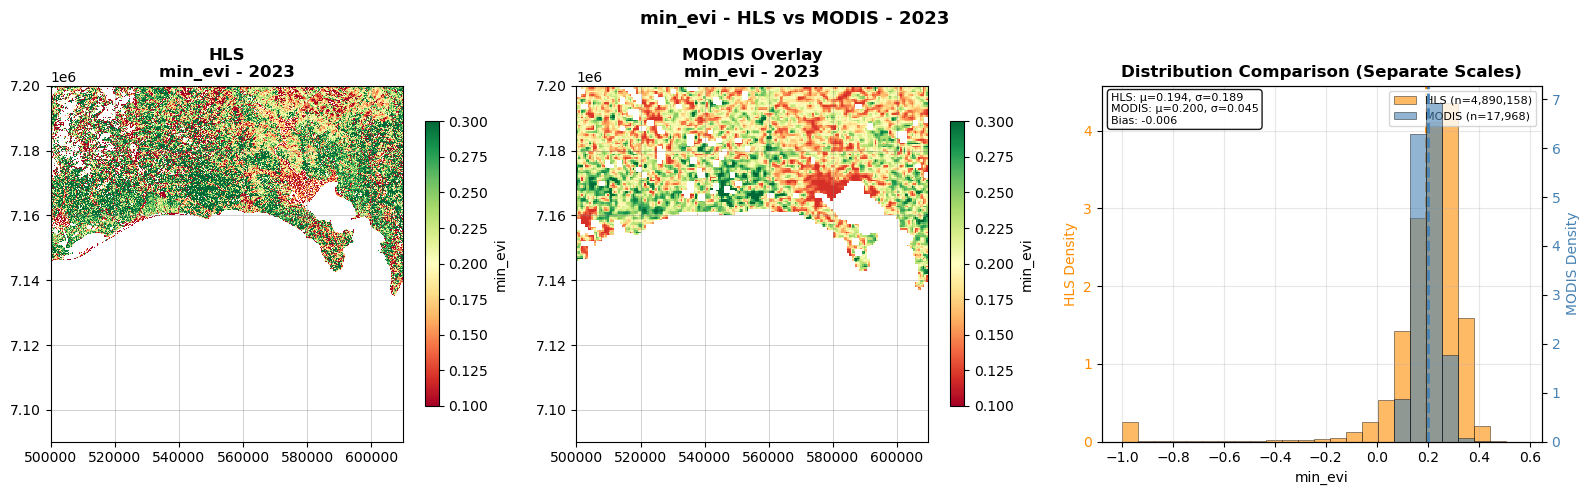

In [255]:
# Visualize
plot_hls_subset_vs_modis(
    hls_subset, 
    modis_aligned, 
    var_name='min_evi', 
    year=years[-1],
    output_dir=OUTPUT_DIR,
    metric_mapping = metrics_config_arctic,
)
plt.show()

In [257]:
import rasterio as rio
def align_grids(modis_data, custom_data, years):
    """
    Resample MODIS (500m) to match HLS grid (30m) using
    nearest neighbour for DOY variables and bilinear for EVI.

    Args:
        modis_data (dict): {var: {year: DataArray}} MODISt
        custom_data (dict): {var: {year: DataArray}} Custom
    Returns:
        dict: {var: {year: DataArray}} MODIS resampled to HLS grid
    """
    # DOY variables — nearest neighbour
    doy_vars = ["greenup_doy", "max_doy", "min_doy", "growing_season_length"]
    
    # Continuous — bilinear (amplitude and max_evi will fall here automatically)
    cont_vars = ["amplitude", "max_evi"]

    aligned = {var: {} for var in modis_data.keys()}

    for var in modis_data.keys():
        resampling = rio.enums.Resampling.nearest if var in doy_vars \
                     else rio.enums.Resampling.bilinear

        for year in years:
            if year not in modis_data[var] or year not in custom_data[var]:
                print(f"  Skipping {var} {year} — missing data")
                continue

            try:
                # Reproject MODIS to exactly match custom grid
                modis_aligned = modis_data[var][year].rio.reproject_match(
                    custom_data[var][year],
                    resampling=resampling
                )
                aligned[var][year] = modis_aligned
                print(f"  Aligned {var} {year} — shape: {modis_aligned.shape}")

            except Exception as e:
                print(f"  Could not align {var} {year}: {e}")

    return aligned
# print("\nAligning MODIS to HLS grid...")
# modis_aligned = align_grids(modis_data, custom_data, YEARS)

In [320]:
import rasterio as rio
from rasterio.enums import Resampling
import numpy as np

def align_and_downsample_hls_to_modis(modis_data, custom_data, years):
    """
    Align HLS and MODIS grids, then downsample HLS (30m) to match MODIS (500m).
    1. Reproject MODIS to HLS CRS (if needed) without resampling
    2. Downsample HLS to MODIS resolution using appropriate method per variable
    """
    # DOY variables — mode (most common value in 500m window)
    doy_vars = ["greenup_doy", "max_doy", "min_doy"]
    
    # Growing season length — mean aggregation
    gsl_vars = ["growing_season_length"]
    
    # EVI/continuous — mean aggregation
    cont_vars = ["amplitude", "max_evi", "greenup_evi", "min_evi"]

    modis_aligned = {var: {} for var in modis_data.keys()}
    hls_downsampled = {var: {} for var in custom_data.keys()}

    for var in modis_data.keys():
        if var in doy_vars:
            modis_method = Resampling.nearest  # Preserve DOY values when reprojecting to HLS grid
            hls_method = Resampling.mode       # Most common DOY in 500m window
        elif var in gsl_vars or var in cont_vars:
            modis_method = Resampling.bilinear
            hls_method = Resampling.average    # Mean of 30m pixels in 500m window

        else:
            print(f"{var} not in current resampling scheme")
            continue

        for year in years:
            if year not in modis_data[var] or year not in custom_data[var]:
                print(f"  Skipping {var} {year} — missing data")
                continue
            try:
                modis_orig = modis_data[var][year]
                hls_orig = custom_data[var][year]
                if hls_orig.rio.nodata is None:
                    print("  Setting nodata value...")
                    hls_orig = hls_orig.rio.write_nodata(np.nan)
                    
                # Step 1: Reproject MODIS to HLS CRS (preserving 500m resolution)
                modis_in_hls_crs = modis_orig.rio.reproject(
                    hls_orig.rio.crs,
                    resolution=500, 
                    resampling=modis_method
                )
                # Step 2: Downsample HLS to match MODIS 500m grid exactly
                hls_downsampled_da = hls_orig.rio.reproject_match(
                    modis_in_hls_crs,
                    resampling=hls_method,
                )
        
                
                modis_aligned[var][year] = modis_in_hls_crs
                hls_downsampled[var][year] = hls_downsampled_da

                print(f"{var} {year}")
                print(f"  MODIS: {modis_in_hls_crs.shape} @ 500m")
                print(f"  HLS:   {hls_downsampled_da.shape} @ 500m (downsampled from {hls_orig.shape} @ 30m)")

            except Exception as e:
                print(f"  Could not align {var} {year}: {e}")

    return modis_aligned, hls_downsampled

In [321]:
modis_aligned, hls_downsampled = align_and_downsample_hls_to_modis(
    modis_data, 
    custom_data, 
    YEARS
)

greenup_doy 2021
  MODIS: (132, 223) @ 500m
  HLS:   (132, 223) @ 500m (downsampled from (3660, 3660) @ 30m)
greenup_doy 2022
  MODIS: (132, 223) @ 500m
  HLS:   (132, 223) @ 500m (downsampled from (3660, 3660) @ 30m)
greenup_doy 2023
  MODIS: (132, 223) @ 500m
  HLS:   (132, 223) @ 500m (downsampled from (3660, 3660) @ 30m)
greenup_doy 2024
  MODIS: (132, 223) @ 500m
  HLS:   (132, 223) @ 500m (downsampled from (3660, 3660) @ 30m)
max_doy 2021
  MODIS: (132, 223) @ 500m
  HLS:   (132, 223) @ 500m (downsampled from (3660, 3660) @ 30m)
max_doy 2022
  MODIS: (132, 223) @ 500m
  HLS:   (132, 223) @ 500m (downsampled from (3660, 3660) @ 30m)
max_doy 2023
  MODIS: (132, 223) @ 500m
  HLS:   (132, 223) @ 500m (downsampled from (3660, 3660) @ 30m)
max_doy 2024
  MODIS: (132, 223) @ 500m
  HLS:   (132, 223) @ 500m (downsampled from (3660, 3660) @ 30m)
min_doy 2021
  MODIS: (132, 223) @ 500m
  HLS:   (132, 223) @ 500m (downsampled from (3660, 3660) @ 30m)
min_doy 2022
  MODIS: (132, 223) @ 500m

In [286]:
def compute_differences(modis_aligned, custom_data, years):

    diffs = {var: {} for var in modis_aligned.keys()}

    for var in modis_aligned.keys():
        for year in years:
            if year not in modis_aligned[var] or year not in custom_data[var]:
                continue
            try:
                diff = custom_data[var][year] - modis_aligned[var][year]
                diffs[var][year] = diff
            except Exception as e:
                print(f"  Difference {var} {year}: {e}")

    return diffs


diffs = compute_differences(modis_aligned, hls_downsampled, YEARS)
# diffs

In [287]:
from scipy import stats
def compute_statistics(modis_aligned, custom_data, diffs, years):

    records = []

    for var in modis_aligned.keys():
        for year in years:
            if year not in modis_aligned[var] or year not in custom_data[var]:
                continue

            # flatten to 1D array
            m = modis_aligned[var][year].values.ravel()
            c = custom_data[var][year].values.ravel()

            # Remove NaNs
            mask = np.isfinite(m) & np.isfinite(c)
            m, c = m[mask], c[mask]

            if len(m) < 10:
                continue

            diff_vals = c - m
            r, p_val = stats.pearsonr(m, c)

            records.append({
                "variable"   : var,
                "year"       : year,
                "n_pixels"   : len(m),
                "bias"       : np.mean(diff_vals),       # HLS - MODIS
                "mae"        : np.mean(np.abs(diff_vals)),
                "rmse"       : np.sqrt(np.mean(diff_vals**2)),
                "r"          : r,
                "r2"         : r**2,
                "p_value"    : p_val,
                "custom_mean": np.mean(c),
                "modis_mean" : np.mean(m),
            })

    df = pd.DataFrame(records)
    return df

In [288]:
stats_df = compute_statistics(modis_aligned, hls_downsampled, diffs, YEARS)

# Save to CSV
# stats_df.to_csv(OUTPUT_DIR / "comparison_statistics.csv", index=False)
print(stats_df.to_string(index=False))

             variable  year  n_pixels        bias        mae       rmse         r       r2       p_value  custom_mean  modis_mean
          greenup_doy  2021     18673   11.458791  19.445081  31.968629  0.103539 0.010720  1.123666e-45   146.264450  134.805655
          greenup_doy  2022     19071   15.167007  22.458078  34.710580  0.066496 0.004422  3.837212e-20   141.504791  126.337790
          greenup_doy  2023     19032   29.968684  31.714586  47.125387  0.200996 0.040399 1.120658e-172   160.712219  130.743537
          greenup_doy  2024     19156   20.913447  23.833159  38.237646  0.276149 0.076258  0.000000e+00   159.632797  138.719357
              max_doy  2021     18673    3.097360  12.351042  18.387428  0.201935 0.040778 4.653895e-171   210.535690  207.438333
              max_doy  2022     19071    0.205495   7.461014  12.708146  0.149893 0.022468  3.085089e-96   202.464890  202.259399
              max_doy  2023     19032   -4.218527  10.629519  15.954665  0.158561 0.025141

In [289]:
def plot_difference_maps(diffs, years, output_dir, tag = None):

    vars_to_plot = list(diffs.keys())
    n_vars = len(vars_to_plot)
    n_years = len(years)

    for var in vars_to_plot:
        available_years = [y for y in years if y in diffs[var]]
        if not available_years:
            continue

        fig, axes = plt.subplots(
            1, len(available_years),
            figsize=(4 * len(available_years), 4)
        )
        if len(available_years) == 1:
            axes = [axes]

        # Symmetric colorbar across all years for this variable
        all_vals = np.concatenate([
            diffs[var][y].values.ravel() for y in available_years
        ])
        all_vals = all_vals[np.isfinite(all_vals)]
        vmax = np.percentile(np.abs(all_vals), 95)
        vmin = -vmax

        for ax, year in zip(axes, available_years):
            diff = diffs[var][year]
            im = ax.imshow(
                diff.values,
                cmap="RdBu_r",
                vmin=vmin,
                vmax=vmax,
                origin="upper"
            )
            ax.set_title(str(year), fontsize=10)
            ax.axis("off")

        fig.colorbar(im, ax=axes, label="Custom − MODIS", shrink=0.8)
        fig.suptitle(f"{var}  |  Custom − MODIS", fontsize=13, fontweight="bold")
        # plt.tight_layout()

    if tag:
        out_fp = output_dir / f"diffmap_{var}-{tag}.png"
    else:
        out_fp = output_dir / f"diffmap_{var}.png"
        
    plt.savefig(out_fp, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved: {out_fp.name}")

def plot_difference_maps_by_year(diffs, year, output_dir, ncols=3, tag = None):
    """
    Plot difference maps for all variables for a single year.
    
    Args:
        diffs (dict): {var: {year: DataArray}} difference data
        year (int): Year to plot
        output_dir (Path): Output directory
        ncols (int): Number of columns per row (default 3)
    """
    from pathlib import Path
    import matplotlib.pyplot as plt
    import numpy as np
    
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True, parents=True)
    
    # Get all variables that have data for this year
    vars_to_plot = [var for var in diffs.keys() if year in diffs[var]]
    
    if not vars_to_plot:
        print(f"No data found for year {year}")
        return
    
    n_vars = len(vars_to_plot)
    nrows = int(np.ceil(n_vars / ncols))
    
    # Create figure
    fig, axes_raw = plt.subplots(
        nrows, ncols,
        figsize=(5 * ncols, 4 * nrows)
    )
    
    # Convert axes to list
    if nrows == 1 and ncols == 1:
        axes_list = [axes_raw]
    elif nrows == 1:
        axes_list = list(axes_raw)
    elif ncols == 1:
        axes_list = list(axes_raw)
    else:
        axes_list = list(axes_raw.flatten())
    
    # Plot each variable
    for idx, var in enumerate(vars_to_plot):
        ax = axes_list[idx]
        diff = diffs[var][year]
        
        # Compute symmetric color scale for this variable
        diff_vals = diff.values[np.isfinite(diff.values)]
        
        if len(diff_vals) > 0:
            vmax = np.percentile(np.abs(diff_vals), 90)
            vmin = -vmax
        else:
            vmin, vmax = -1, 1
        
        im = ax.imshow(
            diff.values,
            cmap="RdBu_r",
            vmin=vmin,
            vmax=vmax,
            origin="upper",
            aspect='auto'
        )
        
        ax.set_title(var.replace('_', ' ').title(), fontsize=10, fontweight='bold')
        ax.axis("off")
        
        # Add colorbar for each subplot
        cbar = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
        cbar.ax.tick_params(labelsize=7)
        
        # Statistics annotation
        if len(diff_vals) > 0:
            bias = np.mean(diff_vals)
            mae = np.mean(np.abs(diff_vals))
            rmse = np.sqrt(np.mean(diff_vals**2))
            stats_text = f"bias={bias:.2f}\nMAE={mae:.2f}\nRMSE={rmse:.2f}"
            ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
                   fontsize=7, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Hide unused subplots
    for idx in range(n_vars, len(axes_list)):
        axes_list[idx].axis('off')
    
    fig.suptitle(f'Difference Maps (HLS − MODIS) - {year}', 
                 fontsize=14, fontweight="bold")
    plt.tight_layout()

    if tag:
        out_fp = output_dir / f"diffmap_all_vars_{year}-{tag}.png"
    else:
        out_fp = output_dir / f"diffmap_all_vars_{year}.png"
        
    plt.savefig(out_fp, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved: {out_fp.name}")


In [290]:
OUTPUT_DIR

PosixPath('output/03WWM/MODIS')

In [291]:
# plot_difference_maps(diffs, YEARS, OUTPUT_DIR, tag = "decid_forest")
plot_difference_maps_by_year(diffs, year=2023, output_dir=OUTPUT_DIR, ncols=3)#, tag = "decid_forest")

Saved: diffmap_all_vars_2023.png


In [292]:
def plot_timeseries_comparison(modis_aligned, custom_data, stats_df, years, output_dir, tag = None):
    """
    Plot spatial mean time series for each variable — 
    MODIS vs Custom with RMSE and bias annotations.
    """
    vars_to_plot = list(modis_aligned.keys())
    fig, axes = plt.subplots(
        len(vars_to_plot), 1,
        figsize=(10, 4 * len(vars_to_plot)),
        sharex=True
    )
    if len(vars_to_plot) == 1:
        axes = [axes]

    for ax, var in zip(axes, vars_to_plot):
        modis_means  = []
        custom_means = []
        valid_years  = []

        for year in years:
            if year not in modis_aligned[var] or year not in custom_data[var]:
                continue
            modis_means.append(float(modis_aligned[var][year].mean()))
            custom_means.append(float(custom_data[var][year].mean()))
            valid_years.append(year)

        ax.plot(valid_years, modis_means,  "o--", color="steelblue",
                label="MODIS MCD12Q2", linewidth=2)
        ax.plot(valid_years, custom_means, "o-",  color="darkorange",
                label="HLS", linewidth=2)

        # Annotate with mean RMSE and bias
        var_stats = stats_df[stats_df["variable"] == var]
        if not var_stats.empty:
            mean_rmse = var_stats["rmse"].mean()
            mean_bias = var_stats["bias"].mean()
            mean_r2   = var_stats["r2"].mean()
            ax.text(
                0.02, 0.95,
                f"Mean RMSE: {mean_rmse:.2f}  |  Mean Bias: {mean_bias:.2f}  |  Mean R²: {mean_r2:.2f}",
                transform=ax.transAxes,
                fontsize=9,
                verticalalignment="top",
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
            )

        ax.set_ylabel(var, fontsize=16)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_xticks(valid_years)

    axes[-1].set_xlabel("Year")
    fig.suptitle(f"MODIS vs HLS — {TILE_ID}",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()

    if tag:
        out_fp = output_dir / f"timeseries_comparison-{tag}.png"
    else:
        out_fp = output_dir / "timeseries_comparison.png"
    plt.savefig(out_fp, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved: {out_fp.name}")

In [293]:
plot_timeseries_comparison(modis_aligned, hls_downsampled, stats_df, YEARS, OUTPUT_DIR)

Saved: timeseries_comparison.png


In [294]:
def plot_scatter(
    modis_aligned, 
    custom_data, 
    years,     
    output_dir, 
    tag=None,
    filter_hls_value=1.0,  # Fixed: use = not ==
):
    """
    One scatter plot per variable — all years combined,
    coloured by year with 1:1 line and regression line.
    
    Args:
        modis_aligned (dict): MODIS data
        custom_data (dict): HLS data
        years (list): Years to plot
        output_dir (Path): Output directory
        tag (str): Optional tag for filename
        filter_hls_value (float): HLS value to exclude (default 1.0, set to None to disable)
    """
    import matplotlib.colors as mcolors
    from scipy import stats
    
    vars_to_plot = list(modis_aligned.keys())
    fig, axes = plt.subplots(
        1, len(vars_to_plot),
        figsize=(5 * len(vars_to_plot), 5)
    )
    if len(vars_to_plot) == 1:
        axes = [axes]

    cmap = plt.cm.viridis
    norm = mcolors.Normalize(vmin=min(years), vmax=max(years))

    for ax, var in zip(axes, vars_to_plot):
        all_m, all_c, all_y = [], [], []
        n_filtered_total = 0

        for year in years:
            if year not in modis_aligned[var] or year not in custom_data[var]:
                continue
            
            m = modis_aligned[var][year].values.ravel()
            c = custom_data[var][year].values.ravel()
            
            # Base mask: remove NaN
            mask = np.isfinite(m) & np.isfinite(c)
            
            # Filter HLS artifact values if specified
            if filter_hls_value is not None:
                artifact_mask = np.isclose(c, filter_hls_value, atol=1e-6)
                n_filtered = np.sum(artifact_mask & mask)
                n_filtered_total += n_filtered
                mask = mask & ~artifact_mask
            
            all_m.extend(m[mask])
            all_c.extend(c[mask])
            all_y.extend([year] * mask.sum())

        all_m = np.array(all_m)
        all_c = np.array(all_c)
        all_y = np.array(all_y)

        if len(all_m) == 0:
            print(f"  Warning: No valid data for {var}")
            continue
        
        # Print filtering summary
        if filter_hls_value is not None and n_filtered_total > 0:
            print(f"  {var}: Filtered {n_filtered_total} pixels with HLS≈{filter_hls_value}")

        sc = ax.scatter(all_m, all_c, c=all_y, cmap=cmap, norm=norm,
                        alpha=0.6, s=2, rasterized=True)

        # 1:1 line
        lims = [min(all_m.min(), all_c.min()), max(all_m.max(), all_c.max())]
        ax.plot(lims, lims, "k--", linewidth=1, label="1:1")

        # Regression line
        slope, intercept, r, _, _ = stats.linregress(all_m, all_c)
        x_fit = np.linspace(lims[0], lims[1], 100)
        ax.plot(x_fit, 
                slope * x_fit + intercept, 
                "r-", 
                linewidth=1.5,
                label=f"y={slope:.2f}x+{intercept:.1f}\nR²={r**2:.2f}")

        ax.set_xlabel("MODIS", fontsize=10)
        ax.set_ylabel("HLS", fontsize=10)
        ax.set_title(var, fontsize=11, fontweight="bold")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        
        if len(years) > 1:
            plt.colorbar(sc, ax=ax, label="Year")

    fig.suptitle(f"MODIS vs HLS — {TILE_ID} SERC", fontsize=13, fontweight="bold")
    plt.tight_layout()

    if tag:
        out_fp = output_dir / f"scatter_comparison-{tag}.png"
    else:
        out_fp = output_dir / "scatter_comparison.pdf"
    plt.savefig(out_fp, bbox_inches="tight", format='pdf')
    plt.close()
    print(f"Saved: {out_fp.name}")

In [295]:
def plot_scatter(
    modis_aligned, 
    custom_data, 
    years,     
    output_dir, 
    tag=None,
    filter_hls_value=None, #1.0,
    dpi=300,
    save_formats=['png', 'pdf'],
    use_heatmap=True,           # <-- Add heatmap option
    heatmap_threshold=1000,     # <-- Switch to heatmap if more than this many points
    gridsize=50,                # <-- Hexbin grid resolution
):
    """
    One scatter plot per variable — all years combined.
    Can use scatter or hexbin heatmap based on point density.
    
    Args:
        modis_aligned (dict): MODIS data
        custom_data (dict): HLS data
        years (list): Years to plot
        output_dir (Path): Output directory
        tag (str): Optional tag for filename
        filter_hls_value (float): HLS value to exclude (default 1.0, None to disable)
        dpi (int): DPI for PNG output
        save_formats (list): Formats to save ['png', 'pdf', 'svg']
        use_heatmap (bool): Use hexbin heatmap for dense data
        heatmap_threshold (int): Number of points above which to use heatmap
        gridsize (int): Hexbin grid resolution (higher = finer detail)
    """
    import matplotlib.colors as mcolors
    from scipy import stats
    import matplotlib.pyplot as plt
    import numpy as np
    
    vars_to_plot = list(modis_aligned.keys())
    fig, axes = plt.subplots(
        1, len(vars_to_plot),
        figsize=(5 * len(vars_to_plot), 4)
    )
    if len(vars_to_plot) == 1:
        axes = [axes]

    cmap_year = plt.cm.viridis
    norm_year = mcolors.Normalize(vmin=min(years), vmax=max(years))

    for ax, var in zip(axes, vars_to_plot):
        all_m, all_c, all_y = [], [], []
        n_filtered_total = 0

        for year in years:
            if year not in modis_aligned[var] or year not in custom_data[var]:
                continue
            
            m = modis_aligned[var][year].values.ravel()
            c = custom_data[var][year].values.ravel()
            
            mask = np.isfinite(m) & np.isfinite(c)
            
            if filter_hls_value is not None:
                artifact_mask = np.isclose(c, filter_hls_value, atol=1e-6)
                n_filtered = np.sum(artifact_mask & mask)
                n_filtered_total += n_filtered
                mask = mask & ~artifact_mask
            
            all_m.extend(m[mask])
            all_c.extend(c[mask])
            all_y.extend([year] * mask.sum())

        all_m = np.array(all_m)
        all_c = np.array(all_c)
        all_y = np.array(all_y)

        if len(all_m) == 0:
            print(f"  Warning: No valid data for {var}")
            continue
        
        if filter_hls_value is not None and n_filtered_total > 0:
            print(f"  {var}: Filtered {n_filtered_total} pixels with HLS≈{filter_hls_value}")

        # Decide whether to use heatmap or scatter
        use_hexbin = use_heatmap and len(all_m) > heatmap_threshold
        
        if use_hexbin:
            # Hexbin heatmap (density plot)
            print(f"  {var}: Using hexbin heatmap ({len(all_m):,} points)")
            lims = [min(all_m.min(), all_c.min()), max(all_m.max(), all_c.max())]
            hb = ax.hexbin(all_m, all_c, 
                          gridsize=gridsize, 
                          # cmap='YlOrRd',  # Heatmap colormap
                          mincnt=1,
                          # bins='log',     # Log scale for better visibility
                          linewidths=0.2,
                          edgecolors='face',
                          extent=[lims[0], lims[1], lims[0], lims[1]])
            ax.set_aspect('equal', adjustable='box') 
            ax.set_xlim(lims)  
            ax.set_ylim(lims)  
            cbar = plt.colorbar(hb, ax=ax, label='Count')
            cbar.ax.tick_params(labelsize=8)
            
        else:
            # Regular scatter plot
            print(f"  {var}: Using scatter plot ({len(all_m):,} points)")
            
            sc = ax.scatter(all_m, all_c, c=all_y, cmap=cmap_year, norm=norm_year,
                            alpha=0.6, s=2, rasterized=False)
            
            if len(years) > 1:
                cbar = plt.colorbar(sc, ax=ax, label="Year")
                cbar.ax.tick_params(labelsize=8)

        # 1:1 line
        lims = [min(all_m.min(), all_c.min()), max(all_m.max(), all_c.max())]
        ax.plot(lims, lims, "k--", linewidth=1.5, label="1:1", zorder=10)

        # Regression line
        slope, intercept, r, _, _ = stats.linregress(all_m, all_c)
        x_fit = np.linspace(lims[0], lims[1], 100)
        ax.plot(x_fit, 
                slope * x_fit + intercept, 
                "r-", 
                linewidth=2,
                label=f"y={slope:.2f}x+{intercept:.1f}\nR²={r**2:.2f}",
                zorder=10)

        # Statistics box
        rmse = np.sqrt(np.mean((all_c - all_m)**2))
        bias = np.mean(all_c - all_m)
        stats_text = f"n = {len(all_m):,}\nRMSE = {rmse:.3f}\nBias = {bias:.3f}"
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
               fontsize=8, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
               zorder=11)

        ax.set_xlabel("MODIS", fontsize=10)
        ax.set_ylabel("HLS", fontsize=10)
        ax.set_title(var, fontsize=11, fontweight="bold")
        ax.legend(fontsize=8, loc='lower right')
        ax.grid(True, alpha=0.3, zorder=0)
        ax.set_aspect('equal', adjustable='box')

    title = f"MODIS vs HLS — {TILE_ID} SERC"
    if filter_hls_value is not None:
        title += f" (filtered HLS={filter_hls_value})"
    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()

    # Save in requested formats
    if tag:
        base_name = f"scatter_comparison-{tag}"
    else:
        base_name = "scatter_comparison"
    
    for fmt in save_formats:
        out_fp = output_dir / f"{base_name}.{fmt}"
        if fmt == 'png':
            plt.savefig(out_fp, dpi=dpi, bbox_inches="tight")
        else:
            plt.savefig(out_fp, bbox_inches="tight", format=fmt)
        print(f"Saved: {out_fp.name}")
    
    plt.close()

In [296]:
plot_scatter(modis_aligned, hls_downsampled, YEARS, OUTPUT_DIR, 
             use_heatmap=False, heatmap_threshold=1000)

  greenup_doy: Using scatter plot (75,932 points)
  max_doy: Using scatter plot (75,932 points)
  min_doy: Using scatter plot (75,932 points)
  amplitude: Using scatter plot (70,516 points)
  max_evi: Using scatter plot (70,516 points)
  growing_season_length: Using scatter plot (63,582 points)
Saved: scatter_comparison.png
Saved: scatter_comparison.pdf


In [297]:
plot_scatter(modis_aligned, hls_downsampled, YEARS, OUTPUT_DIR)#, tag = "decid_forest")

  greenup_doy: Using hexbin heatmap (75,932 points)
  max_doy: Using hexbin heatmap (75,932 points)
  min_doy: Using hexbin heatmap (75,932 points)
  amplitude: Using hexbin heatmap (70,516 points)
  max_evi: Using hexbin heatmap (70,516 points)
  growing_season_length: Using hexbin heatmap (63,582 points)
Saved: scatter_comparison.png
Saved: scatter_comparison.pdf


In [331]:
def plot_modis_vs_hls_comparison(
    modis_data,
    hls_data,
    var_name,
    year,
    output_dir=None,
    vmin=None,
    vmax=None,
    cmap='RdYlGn',
    gdf=None,
    show_difference=True,
    show_histogram=True,
    show_scatter=True,
    figsize=(14, 10)
):
    """
    Plot side-by-side comparison of MODIS and HLS data for a given variable and year.
    Layout: 2 columns with maps on left, stats plots on right.
    
    Args:
        modis_data (dict): {var: {year: DataArray}} MODIS aligned data
        hls_data (dict): {var: {year: DataArray}} HLS downsampled data
        var_name (str): Variable name to plot (e.g., 'greenup_doy')
        year (int): Year to plot
        output_dir (Path): Directory to save output (optional)
        vmin, vmax (float): Color scale limits (None = auto)
        cmap (str): Colormap name
        gdf (GeoDataFrame): Optional shapefile to overlay boundaries
        show_difference (bool): Add difference map panel
        show_histogram (bool): Add histogram comparison panel
        show_scatter (bool): Add scatter plot panel
        figsize (tuple): Figure size
    
    Returns:
        fig, axes: Matplotlib figure and axes objects
    """
    from scipy import stats as scipy_stats
    
    # Validate inputs
    if var_name not in modis_data or year not in modis_data[var_name]:
        raise ValueError(f"MODIS data not found for {var_name} {year}")
    if var_name not in hls_data or year not in hls_data[var_name]:
        raise ValueError(f"HLS data not found for {var_name} {year}")
    
    modis = modis_data[var_name][year]
    hls = hls_data[var_name][year]
    
    # Compute difference
    diff = hls - modis
    
    # Auto-scale if not provided
    if vmin is None or vmax is None:
        valid_vals = np.concatenate([
            modis.values[np.isfinite(modis.values)],
            hls.values[np.isfinite(hls.values)]
        ])
        if len(valid_vals) > 0:
            vmin = vmin or np.percentile(valid_vals, 2)
            vmax = vmax or np.percentile(valid_vals, 98)
        else:
            vmin, vmax = 0, 1
    
    # Difference color scale (symmetric)
    diff_valid = diff.values[np.isfinite(diff.values)]
    if len(diff_valid) > 0:
        diff_max = np.percentile(np.abs(diff_valid), 95)
    else:
        diff_max = 1
    
    # Determine layout - 2 columns
    # Left column: maps (MODIS, HLS, Difference)
    # Right column: stats (Histogram, Scatter)
    n_map_rows = 2 + (1 if show_difference else 0)
    n_stat_rows = (1 if show_histogram else 0) + (1 if show_scatter else 0)
    n_rows = max(n_map_rows, n_stat_rows)
    
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(n_rows, 2, hspace=0.3, wspace=0.3)
    
    # --- LEFT COLUMN: MAPS ---
    row_idx = 0
    
    # Panel 1: MODIS
    ax = fig.add_subplot(gs[row_idx, 0])
    
    im1 = ax.imshow(
        modis.values,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        origin='upper',
        aspect='auto'
    )
    
    if gdf is not None:
        gdf_modis = gdf.to_crs(modis.rio.crs)
        gdf_modis.boundary.plot(ax=ax, edgecolor='blue', linewidth=1.5)
    
    ax.set_title(f'MODIS MCD12Q2 - {var_name}', fontsize=10, fontweight='bold')
    ax.axis('off')
    
    cbar1 = plt.colorbar(im1, ax=ax, shrink=0.9, pad=0.02)
    cbar1.set_label(var_name, fontsize=8)
    
    # Statistics annotation
    modis_valid = modis.values[np.isfinite(modis.values)]
    if len(modis_valid) > 0:
        stats_text = f"n={len(modis_valid)}\nmean={np.mean(modis_valid):.2f}\nstd={np.std(modis_valid):.2f}"
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
                fontsize=7, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    row_idx += 1
    
    # Panel 2: HLS
    ax = fig.add_subplot(gs[row_idx, 0])
    
    im2 = ax.imshow(
        hls.values,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        origin='upper',
        aspect='auto'
    )
    
    if gdf is not None:
        gdf_hls = gdf.to_crs(hls.rio.crs)
        gdf_hls.boundary.plot(ax=ax, edgecolor='blue', linewidth=1.5)
    
    ax.set_title(f'HLS - {var_name}', fontsize=10, fontweight='bold')
    ax.axis('off')
    
    cbar2 = plt.colorbar(im2, ax=ax, shrink=0.9, pad=0.02)
    cbar2.set_label(var_name, fontsize=8)
    
    # Statistics
    hls_valid = hls.values[np.isfinite(hls.values)]
    if len(hls_valid) > 0:
        stats_text = f"n={len(hls_valid)}\nmean={np.mean(hls_valid):.2f}\nstd={np.std(hls_valid):.2f}"
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
                fontsize=7, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    row_idx += 1
    
    # Panel 3: Difference
    if show_difference:
        ax = fig.add_subplot(gs[row_idx, 0])
        
        im3 = ax.imshow(
            diff.values,
            cmap='RdBu_r',
            vmin=-diff_max,
            vmax=diff_max,
            origin='upper',
            aspect='auto'
        )
        
        if gdf is not None:
            gdf_diff = gdf.to_crs(diff.rio.crs)
            gdf_diff.boundary.plot(ax=ax, edgecolor='black', linewidth=1.5, linestyle='--')
        
        ax.set_title('Difference (HLS - MODIS)', fontsize=10, fontweight='bold')
        ax.axis('off')
        
        cbar3 = plt.colorbar(im3, ax=ax, shrink=0.9, pad=0.02)
        cbar3.set_label('Difference', fontsize=8)
        
        # Difference statistics
        if len(diff_valid) > 0:
            bias = np.mean(diff_valid)
            mae = np.mean(np.abs(diff_valid))
            rmse = np.sqrt(np.mean(diff_valid**2))
            stats_text = f"bias={bias:.2f}\nMAE={mae:.2f}\nRMSE={rmse:.2f}"
            ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
                    fontsize=7, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # --- RIGHT COLUMN: STATISTICS ---
    stat_row_idx = 0
    
    # Panel 4: Scatter plot
    if show_scatter:
        ax = fig.add_subplot(gs[stat_row_idx, 1])
        
        # Get paired valid data
        modis_flat = modis.values.ravel()
        hls_flat = hls.values.ravel()
        valid_mask = np.isfinite(modis_flat) & np.isfinite(hls_flat)
        
        modis_paired = modis_flat[valid_mask]
        hls_paired = hls_flat[valid_mask]
        
        if len(modis_paired) > 0:
            # Hexbin for large datasets
            if len(modis_paired) > 1000:
                hb = ax.hexbin(modis_paired, hls_paired, gridsize=30, 
                              cmap='viridis', mincnt=1, alpha=0.8)
                plt.colorbar(hb, ax=ax, label='Count')
            else:
                ax.scatter(modis_paired, hls_paired, alpha=1, s=20,
                          color='steelblue', edgecolors='none')
            
            # 1:1 line
            lims = [
                min(modis_paired.min(), hls_paired.min()),
                max(modis_paired.max(), hls_paired.max())
            ]
            ax.plot(lims, lims, 'k--', linewidth=1.5, label='1:1', zorder=10)
            
            # Linear regression
            slope, intercept, r_value, p_value, std_err = scipy_stats.linregress(
                modis_paired, hls_paired
            )
            x_fit = np.array(lims)
            y_fit = slope * x_fit + intercept
            ax.plot(x_fit, y_fit, 'r-', linewidth=2, 
                   label=f'y={slope:.2f}x+{intercept:.1f}', zorder=11)
            
            # Statistics text
            r2 = r_value**2
            rmse = np.sqrt(np.mean((hls_paired - modis_paired)**2))
            bias = np.mean(hls_paired - modis_paired)
            
            stats_text = (
                f'n = {len(modis_paired)}\n'
                f'R² = {r2:.3f}\n'
                f'RMSE = {rmse:.2f}\n'
                f'Bias = {bias:.2f}\n'
                f'p < {p_value:.2e}'
            )
            ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
                   fontsize=8, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            
            ax.set_xlabel('MODIS', fontsize=9)
            ax.set_ylabel('HLS', fontsize=9)
            ax.set_title('Pixel-wise Comparison', fontsize=10, fontweight='bold')
            ax.legend(fontsize=7, loc='lower right')
            ax.grid(True, alpha=0.3)
            ax.set_aspect('equal', adjustable='box')
        
        stat_row_idx += 1
    
    # Panel 5: Histogram
    if show_histogram:
        ax = fig.add_subplot(gs[stat_row_idx, 1])
        
        # Overlapping histograms
        bins = np.linspace(vmin, vmax, 40)
        
        if len(modis_valid) > 0:
            ax.hist(modis_valid, bins=bins, alpha=0.6, color='steelblue',
                   label=f'MODIS (n={len(modis_valid)})', density=True, 
                   edgecolor='black', linewidth=0.5)
        
        if len(hls_valid) > 0:
            ax.hist(hls_valid, bins=bins, alpha=0.6, color='darkorange',
                   label=f'HLS (n={len(hls_valid)})', density=True,
                   edgecolor='black', linewidth=0.5)
        
        # Add mean lines
        if len(modis_valid) > 0:
            mean_modis = np.mean(modis_valid)
            ax.axvline(mean_modis, color='steelblue', 
                      linestyle='--', linewidth=2, alpha=0.8,
                      label=f'MODIS mean={mean_modis:.1f}')
        if len(hls_valid) > 0:
            mean_hls = np.mean(hls_valid)
            ax.axvline(mean_hls, color='darkorange',
                      linestyle='--', linewidth=2, alpha=0.8,
                      label=f'HLS mean={mean_hls:.1f}')
        
        ax.set_xlabel(var_name, fontsize=9)
        ax.set_ylabel('Density', fontsize=9)
        ax.set_title('Value Distribution', fontsize=10, fontweight='bold')
        ax.legend(fontsize=7, loc='best')
        ax.grid(True, alpha=0.3)
        
        stat_row_idx += 1
    
    plt.suptitle(f'{var_name} Comparison: MODIS vs HLS - {year}',
                 fontsize=13, fontweight='bold')
    
    # Save if output directory provided
    if output_dir is not None:
        output_dir = Path(output_dir)
        output_dir.mkdir(exist_ok=True, parents=True)
        output_path = output_dir / f"comparison_{var_name}_{year}.png"
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {output_path}")
    
    return fig

In [299]:
modis_aligned.keys()

dict_keys(['greenup_doy', 'max_doy', 'min_doy', 'amplitude', 'min_evi', 'max_evi', 'growing_season_length'])

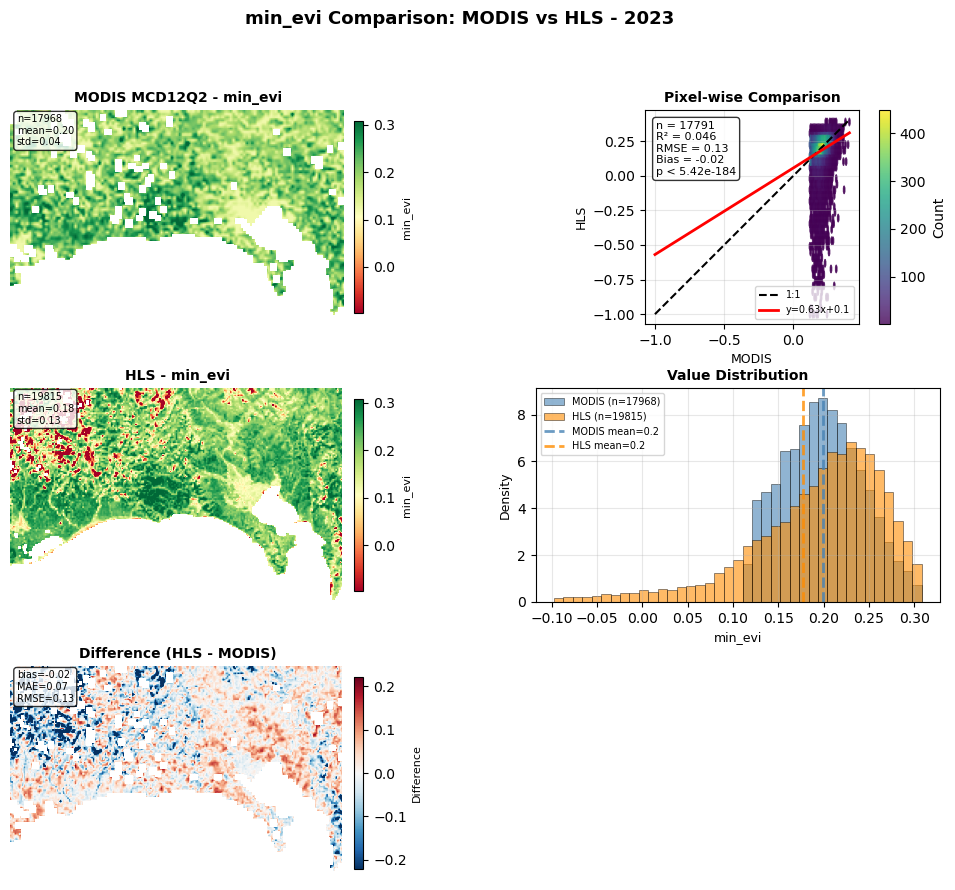

In [332]:
fig = plot_modis_vs_hls_comparison(
    modis_data=modis_aligned,
    hls_data=hls_downsampled,
    var_name='min_evi',
    year=years[-2],
    output_dir=None,
    gdf=None,
    show_difference=True,
    show_histogram=True,
    show_scatter=True,
    figsize=(12, 10)
)
plt.show()


In [85]:
modis_data=modis_aligned
hls_data=hls_downsampled
var_name='greenup_doy'
year=2018
output_dir=None
gdf=gdf
show_difference=True
show_histogram=True

modis = modis_data[var_name][year]
hls = hls_data[var_name][year]

# Compute difference
diff = hls - modis

KeyError: 2018

In [86]:
diff.plot()

NameError: name 'diff' is not defined

In [87]:
# Auto-scale if not provided
vmin=None,
vmax=None
if vmin is None or vmax is None:
    valid_vals = np.concatenate([
        modis.values[np.isfinite(modis.values)],
        hls.values[np.isfinite(hls.values)]
    ])
    if len(valid_vals) > 0:
        vmin = vmin or np.percentile(valid_vals, 2)
        vmax = vmax or np.percentile(valid_vals, 98)
    else:
        vmin, vmax = 0, 1

# Difference color scale (symmetric)
# diff_valid = diff.values[np.isfinite(diff.values)]
# if len(diff_valid) > 0:
#     diff_max = np.percentile(np.abs(diff_valid), 95)
# else:
#     diff_max = 1

# Determine layout
figsize=(18, 4)
n_panels = 2 + (1 if show_difference else 0) + (1 if show_histogram else 0)
fig, axes = plt.subplots(1, n_panels, figsize=figsize)

if n_panels == 1:
    axes = [axes]

panel_idx = 0

# --- Panel 1: MODIS ---
ax = axes[panel_idx]
panel_idx += 1
cmap='RdYlGn'
im1 = ax.imshow(
    modis.values,
    cmap=cmap,
    # vmin=vmin,
    # vmax=vmax,
    origin='upper',
    aspect='auto'
)

# if gdf is not None:
#     gdf_modis = gdf.to_crs(modis.rio.crs)
#     gdf_modis.boundary.plot(ax=ax, edgecolor='blue', linewidth=1)

ax.set_title(f'MODIS MCD12Q2\n{var_name} - {year}', fontsize=11, fontweight='bold')
ax.axis('off')

# Colorbar
cbar1 = plt.colorbar(im1, ax=ax, shrink=0.8, pad=0.02)
cbar1.set_label(var_name, fontsize=9)

# Statistics annotation
modis_valid = modis.values[np.isfinite(modis.values)]
if len(modis_valid) > 0:
    stats_text = f"n={len(modis_valid)}\nmean={np.mean(modis_valid):.1f}\nstd={np.std(modis_valid):.1f}"
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            fontsize=8, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

NameError: name 'modis' is not defined